---
title: Pooled sample-based quantum diagonalization of a nuclear Hamiltonian
description: Pool nuclear Slater determinants from an ensemble of QPU circuits, repair them against exact symmetries, and diagonalize the shell-model Hamiltonian.
---

{/* cspell:ignore Arvidsson Brookhaven Clebsch Condon Gordan Honma Malrieu Mizusaki Mkhize Nesbet Otsuka Rancurel Shukur USDB Yordanov antisymmetrized antisymmetry dets eigh facecolor fontsize frameon labelsize markeredgecolor markeredgewidth multiconfigurational multiplets recoupling spes substate substates tbme tbmes textcoords virtuals wavefunctions xytext zorder */}

# Pooled sample-based quantum diagonalization of a nuclear Hamiltonian

*Usage estimate: 2.5 minutes (NOTE: This is an estimate only. Your runtime might vary.)*

This notebook is the Python implementation of the workflow. The original Fortran version lives in the
[applications/nuclear_shell directory](https://github.com/Qiskit/qiskit-fortran/tree/main/applications/nuclear_shell)
of the Qiskit Fortran repository. This version adds a self-consistent configuration-recovery step,
which the Fortran driver does not perform.

## Learning outcomes

After completing this tutorial, you can expect to understand the following information:

- How a nuclear shell-model Hamiltonian, tabulated in a $J$-coupled basis of orbitals, becomes
  a qubit Hamiltonian in the $m$-scheme, where one qubit is one single-particle state.
- How to build a fixed, non-variational excitation ansatz whose angles come from second-order
  perturbation theory, so there is no classical optimization loop.
- Why a *qubit* excitation is as good as a *fermionic* one for this workflow, and how that one
  substitution cuts the two-qubit depth of the ensemble by several times over.
- How to run self-consistent configuration recovery with `qiskit-addon-sqd` when the conserved
  quantities are nucleon numbers, $M_J$ and parity rather than electron numbers and spin.
- How to take one workflow from a 24-qubit problem you can check exactly to a 40-qubit problem
  with nearly two million basis states, where you cannot.

## Prerequisites

It is recommended that you familiarize yourself with these topics:

- [Sample-based quantum diagonalization](/docs/addons/qiskit-addon-sqd)
  and the [SQD addon reference](/docs/api/qiskit-addon-sqd)
- [Sample-based quantum diagonalization of a chemistry Hamiltonian](/docs/tutorials/sample-based-quantum-diagonalization),
  the electronic-structure counterpart of this tutorial
- [Transpile against a backend target](/docs/guides/transpile)
  and [Introduction to primitives](/docs/guides/primitives)
- Second quantization and the Jordan-Wigner mapping

## Background

The nuclear shell model treats a nucleus as a few *valence* nucleons moving in a small set of
single-particle orbitals above an inert *core*, interacting through an empirical two-body force
fitted to measured spectra. It is the workhorse of low-energy nuclear structure, and its cost is
combinatorial: the basis is every way of distributing the valence protons and neutrons over the
available states, and it outruns exact diagonalization within a few major shells.

Pooled sample-based quantum diagonalization (pooled SQD) [\[1\]](#references) splits that problem in two. A
quantum circuit is used only to *propose* which basis states matter. It is measured in the
computational basis, and each measured bitstring names one Slater determinant. The Hamiltonian is
then built and diagonalized classically in the span of those determinants. Because the classical
step is an exact diagonalization inside a subspace, what it returns is a variational upper bound
on the true ground-state energy, and the bound can only fall as determinants are added.

That division of labour is what makes the method noise-tolerant, and the reason is worth stating
precisely, because it is easy to overclaim. Noise changes *which* determinants the circuit
proposes. It does not enter the classical Hamiltonian, so it cannot move the eigenvalue of a given
subspace: a shot that violates a conserved quantity is discarded or repaired, and a shot that
survives is a legitimate basis vector however it was produced. Noise therefore costs you subspace
quality, not correctness, and the number you report is an upper bound either way.

Nuclear structure suits this better than electronic structure does, because there are more exact
quantum numbers to check. A physical determinant must carry the right number of valence protons
*and* the right number of valence neutrons, the right total angular-momentum projection $M_J$, and
the right parity. Each is an integer test on a bitstring, and each one rejects a large share of the
noise.

![The 24-qubit sd-shell register: three proton orbitals and three neutron orbitals, each split into 2j+1 magnetic substates, one qubit per substate, with the reference determinant of neon-20 filled on the maximal magnetic substates of the 0d5/2 orbital.](/docs/images/tutorials/nuclear_sqd_pooled/sd-shell-register.svg)

Every qubit is one $m$-scheme single-particle state $(n, \ell, j, m_j, t_z)$, and $|1\rangle$ means
occupied. The register is ordered once and for all: protons first, then neutrons; within a species,
orbitals in file order; within an orbital, $m_j$ descending. The two halves of a bitstring are
therefore the proton configuration and the neutron configuration, which is exactly the bipartition
the pooled SQD post-processing tools expect.

### The workflow

![Workflow diagram: a reference determinant feeds an ensemble of shallow excitation circuits, which are sampled on a QPU to produce bitstrings; the bitstrings are repaired and post-selected on proton and neutron number, recombined into a product subspace where the magnetic projection and parity are imposed, and diagonalized to give a variational upper bound; average occupancies from the resulting eigenvector feed back into the next repair.](/docs/images/tutorials/nuclear_sqd_pooled/sqd-workflow.svg)

Two stages in that diagram do the work that is specific to nuclei.

**Repair and post-select** is where hardware noise is spent. The two half-register nucleon numbers
are Hamming weights, so `qiskit-addon-sqd` handles them directly: `recover_configurations` repairs a
broken bitstring by flipping the bits least consistent with the current estimate of the average
orbital occupancies, rather than throwing the shot away.

**The product subspace** is where $M_J$ enters. Because $M_J = M_p + M_n$ couples the two halves, it
is not a property of either one, so it must not be used to filter whole shots: a bitstring whose
proton half and neutron half are each valid still contributes two good half-configurations even when
its total $M_J$ is wrong. The subspace is therefore spanned by every *product* of a sampled proton
configuration with a sampled neutron configuration, keeping the products that land in the target
$M_J$ and parity sector. This is the pooled SQD subspace construction, and it means a few thousand
bitstrings can span a subspace far larger than the sample count.

### Two governing equations

The shell-model Hamiltonian is a one-body term plus a two-body interaction,

$$
\begin{equation}
\tag{1}
H = \sum_{p} \varepsilon_p\, a_p^\dagger a_p
  + \tfrac{1}{4}\sum_{pqrs} \langle pq \| rs \rangle\, a_p^\dagger a_q^\dagger a_s a_r ,
\end{equation}
$$

where $p,q,r,s$ label $m$-scheme states and $t_z = -1$ for a proton, $+1$ for a neutron. Empirical
interactions such as USDA [\[2\]](#references) and GXPF1 [\[3\]](#references) are tabulated not in
the $m$-scheme but in the $J$-coupled basis, as matrix elements $\langle ab; J | V | cd; J \rangle$
between normalized antisymmetrized two-body states of *orbitals* $a,b,c,d$. Recovering the
$m$-scheme element is a Clebsch-Gordan recoupling,

$$
\begin{equation}
\tag{2}
\langle pq \| rs \rangle = \sqrt{1 + \delta_{ab}}\sqrt{1 + \delta_{cd}}
  \sum_{J} \langle j_p m_p\, j_q m_q | J M \rangle
           \langle j_r m_r\, j_s m_s | J M \rangle
           \langle ab; J | V | cd; J \rangle ,
\end{equation}
$$

with the $\sqrt{1+\delta}$ factors undoing the normalization convention of the tabulated states.
Everything else in this tutorial is built on these two equations.

### The three runs

| | Nucleus | Shell | Qubits | Symmetry-allowed basis | Exactly checkable? |
|---|---|---|---|---|---|
| Small-scale | $^{20}\mathrm{Ne}$ (2p + 2n) | $sd$ | 24 | 640 | yes |
| Large-scale | $^{44}\mathrm{Ti}$ (2p + 2n) | $pf$ | 40 | 4,000 | yes |
| Large-scale | $^{48}\mathrm{Cr}$ (4p + 4n) | $pf$ | 40 | 1,963,461 | no |

The small-scale run is the walkthrough. Both large-scale runs use a 40-qubit register: the first is
still small enough to diagonalize exactly on a laptop, so the hardware answer can be scored against
the truth, and the second is not, which is the regime the method exists for.

**Every run here executes on a QPU.** That is a choice made for this tutorial rather than a
requirement of the method: the small-scale run is small in problem size, not in fidelity, so all
three runs share a backend and a gate budget and stay directly comparable.

## Requirements

Before starting this tutorial, be sure you have the following installed:

- Qiskit SDK v2.0 or later (`pip install qiskit`)
- Qiskit Runtime v0.40 or later (`pip install qiskit-ibm-runtime`)
- SQD addon v0.12 or later (`pip install qiskit-addon-sqd`)
- NumPy, SciPy and Matplotlib (`pip install numpy scipy matplotlib`)
- An IBM Quantum&reg; account with saved credentials, and access to a QPU of at least 40 qubits

No simulator package is needed, and no data files have to be downloaded: the two interaction files
this tutorial uses are embedded in the following setup cell and written to a temporary directory when you
run it.

## Setup

This section imports the tools and defines the shell-model helpers the workflow needs, in the order
the workflow uses them. The physics behind each one is derived in the [Appendix](#appendix); the
comments here say what each function does, not why it is correct.

Two interaction files are unpacked first. Both are published parameter sets, embedded here so the
notebook is self-contained: `usda.snt` is the USDA $sd$-shell Hamiltonian [\[2\]](#references) and
`gxpf1.snt` is the GXPF1 $pf$-shell Hamiltonian [\[3\]](#references).

In [1]:
from __future__ import annotations

import base64
import gzip
import itertools
import tempfile
from dataclasses import dataclass
from functools import lru_cache
from math import factorial, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.counts import bit_array_to_arrays
from qiskit_addon_sqd.subsampling import postselect_by_hamming_right_and_left
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

from scipy.linalg import eigh

_USDA_SNT_GZ = (
    "H4sIAI5wqWoC/4WY224bRwyG7/UU9F0CONsZco5AUyBuC/QmQNG06KWhWGql1LYMy+kJefiOTrucGXJrQAgsf5nl8ecOr+CX"
    "D9+9g/0K9pv1/T389rx7gPLrsH+Cz/vVctg+vgAsrgB+HeDdAD9t7zYv6+dr+DDA+z8223/X17B8XMFN+ev9+m+4ed799XjA"
    "f9z8sy/4+s8BvoWYrsEERwbhFRqTXi+uCvOwW63vYf+0vFvDAgDo/AFIh8/hK7DH30354Omvb8o3V8c/vIUnMKtboK/wiGKF"
    "+gnFEfVn9PQUe8bthNIRtftbsGfUtQbAGXUFfawM8K0BF9SP6MWA0BpwQcMRvRhwBSX86+fl3ct2d4jq4+eHa3hYv2x2q7fX"
    "AJuPy+fb3cP69+Uh4luAT8djv95++eGV/fj6y6dvFudnmcX4lGOoBmttNOVncTL2FLs3NGT0l++ndJTv0cR8/t6NUanP8WMI"
    "6nPC6C8/5wp+vnn//QLOP9ank3k2wRszkDn/Zwv15xiv41l2SDmjhuEFM4PJ0QkYcgzM4A1Jp1GDkcvtaWMAR9tosAa9huHk"
    "AtoUBYwaF8hGarAxOywgxnoeN+Se2smF4H3QMPZQ653XMJpOi6GyrcLcZJtzLgoYcdsOyXKibV1Aom0fikJO0VLUMDeW3kAl"
    "qQLWpd66qGE02eZ9lXqSPD3UWyl5DeOeGnINJnmaUggCVrtgh2DJNm3fVy8WF3LSMFa9hYga5iYX0IQsYK2nmTpJkoq81Acy"
    "jLTTnPEaxqo3JGcbvZMeGnJVbw6mf2cUqcIsO80nFdOFq8JoSlY+Zb7FfNNZlnw2PqOE8SL3PtlSJhJGXGqsDRjbh4bmocWy"
    "oiIxSxjv09JYgaxlGLZxA9EFFOImuIBt3EB04TK3Z5S8wizrrFCJQ4Xpgl9hzDYbu0LCNm6HzkJHweUkYazITalyF7NjGAnh"
    "FZJFQniFZFHnqWgbdZ6qtoX50VZhvEJ81TJe7AUcQozH8yQMJ8ymUS07jLin6LXT3FRIhmwSTmtbJpEjr2AsvM7E1ra+ZaiM"
    "NoxewZinBlPQTmPJyikn7TQ2630SbWuz4CLlwzuGhCHPqbUmRZQwpkiBDn1vsoQ55oKjbEvNNVgbXls0WvA0NKnPpku91Fkx"
    "pahhXPDJtxVCQkBcMtJD27I8VJGAhWYYlVuZzc5e+jSIZWnLa57nOQ1iWZY+jSE3GP5/QIKi5E1Agqi9BbMZiUjEWNwChqKq"
    "KTZY11ku5ca2Pqc4YKk1o2DstBjJC1htW2nAgEZ4aDdPvQmmmLeY4tWFt9Y3VAdlpW+oDcpa3zpM1jdUB2XV9agOyqrrcWZQ"
    "sq7vMMffBseux5l5yjoLZ+Yp6yzU5mmt5DgzT5mSozZPoVIknJmnTJFQHZRV12OrlvpFQFbycoGKOWiYfl9QlXySGtSUvL9W"
    "VJi/YG4grC4CmuCX6CZrKUsY64UyJolCQoZJqWeKhDOCzxQJNcGXbZMEX7EtzF+gvCI1npxjmKaW5Q06ewVjOY0u2+Y0kt5D"
    "JhlETS2P+5CqyIMYkCI1NK50SO3TarSR2qfVaKOZPmXjg2beVJmS01zqp/CSmvoqvNSOD/kaS+qUoSGaTM2yz83fdjtMvsZy"
    "xOv7N44Fff/GT5q5tXWYfB3jWND3b9yumUvK5SQnvK6w/VuHyfu3DpP3bx0m7984FvT9W4fJ+zceWq/v3zpM3r9xLOj7tw6T"
    "928X053QgGz/1mHy/u3yZ8lTtn/jWND3b74NiDx2vRbeep56Lbz1oPRaeOv9G0dmxofXPK33bx0m798C1B9RuP4DPJ0WcLAa"
    "AAA="
)

_GXPF1_SNT_GZ = (
    "H4sIAI5wqWoC/4WcQY8dtw3H7/kU41sCeF8lUqKkQw9NgbaXoEHQQ26BkdiIEWdt2E6L9tNXb9+ORIn8PwdZILB/S3I4IsW/"
    "ZiYvjr//+P3f4nG8ef/x+PDm4dOvr9+9++rF8d3l+Mf7x99fvTz+dTn++fnTH7/1//z28pfL8e3H9/95fHm8evzl+lffvf3f"
    "H59e/fb26L9zHN//+t9Pl+OH1/++HH89JL88gkQO8esfvjm+phDomyvW//39/S+v3x2fPrz6+fVX/dfS889B4fpz/aN43P7p"
    "f3Bw/ynH8fD0Zy+uf/fn48MR3vxU/kRXlp7Z+PzDiqUnNn74iW8sb3azYvm0m29s2uxGxabTbryx2cZ7nGzu7KOKV2y8g5Un"
    "dsZbbLyDLafd53irjXew9bR7jffF8fbx8+uPr37+/Pb941dPv3P93ZH4W/If6kUohXCm+Jbmh3yR0jicybwl9CFeuFILy908"
    "HtIlcrlZyCNJ2q6MdGi7ZVy4tlvHJS52Y71FnHp8D+HCIYTlQuYFhdsv0yVxzZB6vsxwaZwJUumkIjWB1POdDhcqlR2KVo85"
    "SoDU8NgdNodiZevqMUqB1LCVWsO2ZMQlyYs+bXEFk4m5bMJJlVgSpGjaouhQvFKxUIbUjIvI85hWW4FNvubyDnMxMkFKRc8V"
    "Uml65OhQW1x9fe3XOAtsZPXJ36TIX18SaoQUnysnZsHUXPfcKqTyaSu36FHbWg0tN0jxWIXEAVLzbqcqkMpj3T8lwlBp9RhD"
    "qpAaHpnzni9nRXPh6lDbysmJBVLzDtU71KztnDxqW1+JhDaKnTtUa4DUzH00Hp0VXQMHSM3c16irlpf7GEcN1dogpfpEDpAa"
    "WRUOBKl0UqkIQ2qs+5IYU6OvthbFodIaF6/9i51VeF0TLZSN2lfh9T729utQOqtXKi/dl/21mihhW+M+BpIKqblypDWHSntc"
    "mSA1O3nMe+6dHp0DEaRmXCU0h9p7dOYCqVm1MehOnvy7nWphSKnuu+Q++X2Ca4uQGrYkxp3yMkFLL0ygavPovmR64dhFY5QM"
    "KVK1XRxqX4UydlHCXU44hY1ydndKuUBK11BzqH1NNOKNMvt27PMXVUWBemSqCVIjrr4nYFtzTSQJkJp3O7se09p9YygCKVL7"
    "UN4opx5DNnE5q5AlerZ2jyExpEYmggTtMYFrzC1Bak58jetGeSvHenSip9ROik0m5lqdsxzjrCYhTM1uImOHYZzVPvnWjXIm"
    "0RoaKyqhjjlqiEE3uWoYHqopbT/KY0pDD+Xtx9d8lvI0n6U8zWcpT/NpQqDms5Sn+TRVoOazlKf5LOVpPk1VqPl05AI1n6U8"
    "zaepAjWfpTzNp6kKNZ/OQoGaz1Ke5rOUp/k0VaHm03mvUPOd1+esL6X5LOVpPkt5ms9SnubTVIGaz1Ke5rOUp/ks5Wk+TVWo"
    "+SzlaT69mgVqPk0VqPks5Wk+S3maT1MVaj5dPwVqPkt5mk9TFWo+S3ma77x/8z56ms9SnuazlKf5LOVpPkt5ms9SnubTVIWa"
    "z1Ke5jupfRWumk9TBWo+S3maz1Ke5rOUp/k0VaHms5Sn+XTnLVDzWcrTfJqqUPNZytN85/1z7rbSfJbyNN/5t06fUJrPUp7m"
    "OykvE7T0wgqqdmo+Mb3Q03yCO6bSfII7ptJ8gruc0nxi+pen+eROL5yaT3CXU5pPx1Sh5hNcj0rzCajHVfMJqMdV88mdesyu"
    "xwo1n+B6VJpPcD0qzSe4HpXmE1yPSvMJrkelwERVR4Waz1Ke5hNTQ3THoxO90nzFZMLTfAVnVWm+grOqNF/BWVWaTxMVar6C"
    "r1FpvgK6yar56vbja76onormu8/5ViqOrNblZH6l0NPAlRq9sKaIbaFnhis15tUuH/E1oieLK1XOTIgsz3ROap9XpQ/SJWqK"
    "bCYcKm6K4tp9iUqqzbd1j4qO+g2tpTV6sll1qLipk6fnw32/isDWPSruPborwz7x9eakKbbry6Gi7RN9nrhuHr4tPXXsVLT9"
    "vvTdKlUQ18i9Q0Wn+2ZOlYpva0yiDhXthNz69p4S+7ZG7h0q2jma+/BIIfm2RnU4VLQ9R6hG4iWryVurhorOlNbzEJr4tubk"
    "bim6e25iqbFbJY4MKfREfaXGNXKK2aF2BSapD6Oy5162yd1S5Og0iq3k5tua1WEpsus+ZO4ZS76tqU4sRc7+mAtJyL6teR8t"
    "RVbDUO9yXM2a2O6jQ5GjdCi3HKpva04dluK7J1uWGtFLjhFS6J2HlZpKhzOm0JsRK5XnmjD7Izv5av0eBd7zVb5IsVU6ffTN"
    "oQXf1peoeveNjZWaNURFZ0L8fTsX1s9hwO4eeHkOA3Z3Zct6ZOccgPAM0O91hR4ZPEcWMAPkdBWQvsdZj72xZuTRs2U95qFY"
    "a8FZHVQpy/Mhd55YbGmPew2VGB2PRvOVsNlib0orYbO1U8fi0cbF6uQhw7jUycMybYs/dSiKwGxyLB5tXEmdM5WM4lKnGLFm"
    "FFeaPTruK8ehlEcbV55n2yIwrnlOXorAuPKsxyIwrjz7l3greptzSgve+tqo2lLbcu9MQ4oiPDMpjzaueR8rUUZxqaql/T46"
    "k5WiCM9fyuNpy5uZpM9WkvfaxpS1Ndd96JKV2LflUdrW1idaKOT0HNMnTCdnT/OZvcOZv5RHG5fqAJFhXLO2WykwrtlzJkV4"
    "llMebVxp7kOUMopr7h1dSmcUl9LuxesT2z6kPOq4ttkkk7sj1/1JWWWnHvfdfVKE50LlUV+jObPqs2hO+zViytpSJ+CFSyu+"
    "LY+yttRM3gf3HH1bHmVtzR5NXZQXcI0epW1tdyh2d86a2O52F9vR6V8FUgTm1dWjjWuepZUgMK45k2cKMC6PIjD7rh6j+gpi"
    "0Y904b675/n2h3u6QteTedkoc7qy2LIeaUxpkXNAHgeV53khozOYxZb1qDpTrvAa+TxBClECvEbPlvWY5o4cA7zGNDSfFIbX"
    "6NmyHmd1SEnwGgfVJ6YKr9GzZT3KebdDZIYe5bzGQLFAj54t7XHXfDkmJ6v789r17e7iTEMrxXhmUh5tXHNmainCuObMVBOO"
    "y6MYzEyrx9MW2VMf4cC9NWlbzpmVoqytucPkIO12SsZ4/lKUtTX7V6LGsfi2phadlLa1nX89naUHc437uYnQni/nlEzWN/S8"
    "s7TVo41LvUsW9+pwqFBl79HsPYkVr/sK9GjjYnVWSzBfqjoowXx5FN+ZC6dHG5d6WybjfM15ouYE8+VRDObC1aOOa3v+WEJq"
    "Tlzb2VCRELOtbYEU47NH5dHGpd5nagzj0s+HAozLoxjMq6tHnfutHmNjblz23G/1qChra3rMOT6f3jGefRVlbamZKfR1COKa"
    "PWdS1tZcXy3mnMm3pd4IGpS1Nd9Uai0Wir6t+fxxUtrWPvu27M1MG8XJ1KMz+yqK8Vmt8mjjmn1CKmcUF88zhVIzimtOtZNi"
    "fO6rPGpbW9XGLrg50G5rfwNhUueu7swmEtI55yQ0m/RpqI3JPd15ujVtWY9TSbcxpSU8dSShAj16tk4b3r6dmUlI2/L27Ulp"
    "W7vKLFK3uByK4nI2VP19SFEJ7EOrRxvXyESr413YhPchLsssV/0dRlEJ70PKo7a1n/vWa1rLbsu8mTooa0up8tpyEd+Wep42"
    "KG1rf6su5ebkvpqztLzl3qltRSVc28ojmTM+9F2TwNm3Qgp9/eSeKnaNXFtwqH3nk1KaJE05M6ZDOdNjv9NJIvm2Zr+3lFeP"
    "EvqGnH1bM/eWMtNQvFCRHnzUlJlzXMqZYFKqHHLxbdFUFIbiu+8XWmo+50vL6R06l1u/PBO/asN8B5zAmdXTDtP7r8h+jeWL"
    "lFOPocYumti39SWq3v0iTvxdtDw9hhmUq9N6PbaqvzJyqyNeMi0nIm51LLbojgIrOUKP+l2yBj16tghrqxib1gqg0pLknfIq"
    "bdoirJqkMMNrnDNATPgaPVuE9VBv0J7HbU107V42W44eUhSjPrF4JKyHUokZxqXeTV+exAI9pCjGp/zKIwE9dO2+XSTX1vbc"
    "b6pJUYT1UOCWWw2+rdmZJkVYD1Ef0Uoi39acySdFWA9RztLVjm9LPQ0cFAENc3unJjrVsWuY0mK297EYxbrbcs7vlUfCGib3"
    "bQ/GNWffMijCGkZRDHr0w+KRsIbpnem6dnZbe9VOitTsW7e3I+e7Pgnv7tfHQxvl7O7KlvU4zu95fouUUNV21RSGFk2oHhdb"
    "ZGbf+b4cXf8nRlnb8maASVlbc+UkSnSb0hKox4eFIjNHz7c/aHydkvC6T9Lydo3Je+u8ZSdf+xsu06O2ta2vPr70W1l2W9v6"
    "UhSbPoG+kwYnSDVnTKGvqYvfv3JuDVLom2vvpOZpvh9fizHuX71jVp79vqDcG8rrJolLnecTxe8TgMLfBTDoJteOGUVntYJr"
    "5PHOVsKnUaEuJw8oE9MWA5V5e2tA9wmQrw5xQB6RrernS33VkEB1PCmKW5f7P6zudeW7TwAA"
)

DATA = Path(tempfile.mkdtemp(prefix="nuclear_sqd_"))
for name, blob in (("usda.snt", _USDA_SNT_GZ), ("gxpf1.snt", _GXPF1_SNT_GZ)):
    (DATA / name).write_bytes(gzip.decompress(base64.b64decode(blob)))

    if not (DATA / name).is_file():
        raise RuntimeError(f"{name} did not unpack to {DATA}")

### The model space and the qubit register

An `.snt` file holds the model space, the single-particle energies, and the $J$-coupled two-body
matrix elements. Two header fields matter and are easy to misread: on the two-body header line, the
third and fourth numbers are *not* an oscillator frequency and a core energy but the reference mass
$A_{\mathrm{ref}}$ at which the interaction was fitted and the exponent of its mass dependence. Both
files carry exponent $-0.3$, with $A_{\mathrm{ref}} = 18$ for USDA and $42$ for GXPF1, so the
tabulated matrix elements must be rescaled by $(A/A_{\mathrm{ref}})^{-0.3}$ for the nucleus being
computed [\[2\]](#references)[\[3\]](#references). Single-particle energies are not rescaled. Skipping
this step changes the correlation energy by a few percent.

The energies that follow are *valence* energies, measured from the inert core; they are not experimental
separation energies.

In [2]:
@dataclass(frozen=True)
class Orbital:
    idx: int
    n: int
    ell: int
    j2: int
    tz: int  # j2 = 2j; tz = -1 proton, +1 neutron


@dataclass(frozen=True)
class SPState:
    """One m-scheme single-particle state, i.e. one qubit."""

    orb: int
    j2: int
    mj2: int
    tz: int
    ell: int
    spe: float  # mj2 = 2 * m_j


@dataclass
class ModelSpace:
    orbitals: list
    spes: dict
    tbmes: dict
    core_z: int
    core_n: int
    mass_number: int
    a_ref: int
    mass_exponent: float
    mass_factor: float


def read_snt(path, n_protons, n_neutrons):
    """Parse a .snt interaction file, applying its mass dependence for this nucleus.

    The two-body header line is ``n_tbme  method  A_ref  exponent``.  When ``method`` is 1 the
    tabulated matrix elements are rescaled by ``(A / A_ref) ** exponent``, where A is the mass
    number of the whole nucleus -- the core plus the valence nucleons.  A is derived from the
    file's own core numbers rather than passed in, so it cannot silently disagree with the
    valence counts the rest of the workflow uses.  Single-particle energies are not rescaled.
    """
    rows = [
        ln.split("!")[0].split() for ln in Path(path).read_text().splitlines()
    ]
    rows = iter([r for r in rows if r])

    n_p_orb, n_n_orb, core_z, core_n = (int(x) for x in next(rows)[:4])
    orbitals = [
        Orbital(*(int(x) for x in next(rows)[:5]))
        for _ in range(n_p_orb + n_n_orb)
    ]

    spes = {}
    for _ in range(int(next(rows)[0])):  # "i  i  <i|H(1b)|i>"
        field = next(rows)
        spes[int(field[0])] = float(field[2])

    n_tbme, method, a_ref, exponent = next(rows)[:4]
    n_tbme, method, a_ref, exponent = (
        int(n_tbme),
        int(method),
        int(a_ref),
        float(exponent),
    )
    mass_number = core_z + core_n + n_protons + n_neutrons
    factor = (mass_number / a_ref) ** exponent if method == 1 else 1.0

    tbmes = {}
    for _ in range(n_tbme):  # "a  b  c  d  J  value"
        field = next(rows)
        tbmes[tuple(int(x) for x in field[:5])] = float(field[5]) * factor

    return ModelSpace(
        orbitals,
        spes,
        tbmes,
        core_z,
        core_n,
        mass_number,
        a_ref,
        exponent,
        factor,
    )


def m_scheme_states(ms):
    """The qubit register: protons then neutrons, orbitals in file order, m_j descending."""
    return [
        SPState(o.idx, o.j2, m2, o.tz, o.ell, ms.spes[o.idx])
        for tz in (-1, +1)
        for o in ms.orbitals
        if o.tz == tz
        for m2 in range(o.j2, -o.j2 - 1, -2)
    ]

### Clebsch-Gordan recoupling

Eq. (2) needs Clebsch-Gordan coefficients for half-integer angular momenta. Every argument is
passed as *twice* its physical value, so $j = 5/2$ enters as `5` and the arithmetic stays exact.

`Interaction.v_ms` is the only place the interaction file is touched. An `.snt` file stores each
matrix element once, so a lookup might need the pair-exchange phase $(-1)^{j_a + j_b - J}$ on either
side, and the bra and ket might be stored in either order.

In [3]:
@lru_cache(maxsize=None)
def clebsch_gordan(j1_2, j2_2, J_2, m1_2, m2_2, M_2):
    """<j1 m1 j2 m2 | J M>.  Every argument is twice its physical value."""
    if m1_2 + m2_2 != M_2 or not abs(j1_2 - j2_2) <= J_2 <= j1_2 + j2_2:
        return 0.0
    if abs(m1_2) > j1_2 or abs(m2_2) > j2_2 or abs(M_2) > J_2:
        return 0.0
    if (j1_2 + j2_2 - J_2) % 2 or (j1_2 - m1_2) % 2 or (j2_2 - m2_2) % 2:
        return 0.0

    f, half = factorial, lambda x: x // 2
    prefactor = sqrt(
        (J_2 + 1)
        * f(half(j1_2 + j2_2 - J_2))
        * f(half(j1_2 - j2_2 + J_2))
        * f(half(-j1_2 + j2_2 + J_2))
        / f(half(j1_2 + j2_2 + J_2) + 1)
        * f(half(J_2 + M_2))
        * f(half(J_2 - M_2))
        * f(half(j1_2 - m1_2))
        * f(half(j1_2 + m1_2))
        * f(half(j2_2 - m2_2))
        * f(half(j2_2 + m2_2))
    )
    total = 0.0
    for k in range(half(j1_2 + j2_2 - J_2) + 1):
        d = [
            half(j1_2 + j2_2 - J_2) - k,
            half(j1_2 - m1_2) - k,
            half(j2_2 + m2_2) - k,
            half(J_2 - j2_2 + m1_2) + k,
            half(J_2 - j1_2 - m2_2) + k,
        ]
        if all(x >= 0 for x in d):
            total += (-1) ** k / (
                f(k) * f(d[0]) * f(d[1]) * f(d[2]) * f(d[3]) * f(d[4])
            )
    return prefactor * total


class Interaction:
    """Antisymmetrized m-scheme two-body matrix elements <pq||rs>, per Eq. (2)."""

    def __init__(self, model_space, sp):
        self.ms, self.sp, self._cache = model_space, sp, {}

    def _tbme(self, oa, ob, oc, od, J, j_ab_2, j_cd_2):
        """<oa ob; J|V|oc od; J>, allowing for how the file happens to order each pair."""
        table = self.ms.tbmes
        # |ba; J> = -(-1)^(j_a + j_b - J) |ab; J> for a normalized antisymmetrized pair;
        # dropping the leading minus makes v_ms symmetric instead of antisymmetric, and
        # the Hamiltonian then fails the rotational-invariance check in Step 1.
        phase_ab = -1.0 if (j_ab_2 // 2 - J) % 2 == 0 else 1.0
        phase_cd = -1.0 if (j_cd_2 // 2 - J) % 2 == 0 else 1.0
        for keys, phase in (
            (((oa, ob, oc, od), (oc, od, oa, ob)), 1.0),
            (((ob, oa, oc, od), (oc, od, ob, oa)), phase_ab),
            (((oa, ob, od, oc), (od, oc, oa, ob)), phase_cd),
            (((ob, oa, od, oc), (od, oc, ob, oa)), phase_ab * phase_cd),
        ):
            for key in keys:
                value = table.get(key + (J,))
                if value is not None:
                    return value * phase
        return 0.0

    def v_ms(self, p, q, r, s):
        """<pq||rs>, zero unless M_J and charge are conserved."""
        cached = self._cache.get((p, q, r, s))
        if cached is not None:
            return cached

        P, Q, R, S = (self.sp[i] for i in (p, q, r, s))
        value = 0.0
        if P.mj2 + Q.mj2 == R.mj2 + S.mj2 and P.tz + Q.tz == R.tz + S.tz:
            M = P.mj2 + Q.mj2
            # sqrt(1 + delta): undo the normalization of the tabulated pair states
            c12 = sqrt(2.0) if (P.tz == Q.tz and P.orb == Q.orb) else 1.0
            c34 = sqrt(2.0) if (R.tz == S.tz and R.orb == S.orb) else 1.0
            for J2 in range(
                max(abs(P.j2 - Q.j2), abs(R.j2 - S.j2)),
                min(P.j2 + Q.j2, R.j2 + S.j2) + 1,
                2,
            ):
                cg_bra = clebsch_gordan(P.j2, Q.j2, J2, P.mj2, Q.mj2, M)
                cg_ket = clebsch_gordan(R.j2, S.j2, J2, R.mj2, S.mj2, M)
                if abs(cg_bra) < 1e-12 or abs(cg_ket) < 1e-12:
                    continue
                value += (
                    c12
                    * c34
                    * cg_bra
                    * cg_ket
                    * self._tbme(
                        P.orb,
                        Q.orb,
                        R.orb,
                        S.orb,
                        J2 // 2,
                        P.j2 + Q.j2,
                        R.j2 + S.j2,
                    )
                )

        self._cache[(p, q, r, s)] = value
        return value

### Matrix elements and the symmetry test

A determinant is a sorted tuple of occupied qubit indices. Two determinants differing in more than
two occupied states have a vanishing matrix element; otherwise the Slater-Condon rules give a short
sum over the interaction, times a fermionic sign counting how many occupied states lie between the
operators in the fixed register ordering.

`symmetry_allowed` is the integer test that all four exact quantum numbers reduce to. It is used both
to filter samples and to enumerate the exact basis for the runs small enough to check.

In [4]:
def matrix_element(inter, det_a, det_b):
    """<A|H|B> for two determinants, each a sorted tuple of occupied qubit indices."""
    set_a, set_b = set(det_a), set(det_b)
    out_a, out_b = sorted(set_a - set_b), sorted(set_b - set_a)
    if len(out_a) != len(out_b) or len(out_a) > 2:
        return 0.0

    if not out_a:  # diagonal: one-body plus two-body
        return sum(inter.sp[i].spe for i in det_a) + sum(
            inter.v_ms(i, j, i, j)
            for i, j in itertools.combinations(det_a, 2)
        )

    if len(out_a) == 1:  # one state moves, p -> q
        p, q = out_a[0], out_b[0]
        crossings = sum(1 for k in set_a if min(p, q) < k < max(p, q))
        return (-1.0) ** crossings * sum(
            inter.v_ms(p, j, q, j) for j in det_a if j not in (p, q)
        )

    (p, r), (q, s) = out_a, out_b  # two states move
    crossings = sum(1 for k in set_a if p < k < r) + sum(
        1 for k in set_b if q < k < s
    )
    return (-1.0) ** crossings * inter.v_ms(p, r, q, s)


def subspace_hamiltonian(inter, dets):
    """Dense real-symmetric H projected onto the span of `dets`."""
    H = np.zeros((len(dets), len(dets)))
    for a, det_a in enumerate(dets):
        H[a, a] = matrix_element(inter, det_a, det_a)
        for b in range(a + 1, len(dets)):
            H[a, b] = H[b, a] = matrix_element(inter, det_a, dets[b])
    return H


def ground_state(inter, dets):
    """Lowest eigenvalue and eigenvector of H over `dets`."""
    values, vectors = np.linalg.eigh(subspace_hamiltonian(inter, dets))
    return values[0], vectors[:, 0]


def symmetry_allowed(
    sp, det, n_protons, n_neutrons, mj2_target=0, parity_target=0
):
    """The four exact shell-model quantum numbers, as integer tests on one determinant."""
    n_p = sum(1 for i in det if sp[i].tz == -1)
    return (
        n_p == n_protons
        and len(det) - n_p == n_neutrons
        and sum(sp[i].mj2 for i in det) == mj2_target
        and sum(sp[i].ell for i in det) % 2 == parity_target
    )


def full_basis(sp, n_protons, n_neutrons, **targets):
    """Every symmetry-allowed determinant.  Only tractable for small model spaces."""
    protons = [i for i, s in enumerate(sp) if s.tz == -1]
    neutrons = [i for i, s in enumerate(sp) if s.tz == +1]
    return [
        p + n
        for p in itertools.combinations(protons, n_protons)
        for n in itertools.combinations(neutrons, n_neutrons)
        if symmetry_allowed(sp, p + n, n_protons, n_neutrons, **targets)
    ]


def count_basis(sp, n_protons, n_neutrons, mj2_target=0, parity_target=0):
    """How many determinants `full_basis` would return, without enumerating them.

    A dynamic program over (occupied count, sum of 2*m_j, parity) per species.  This stays
    cheap when the basis itself is far too large to build, which is how the largest run below
    can report the size of the space it is sampling from.
    """

    def species(states, k):
        table = {(0, 0, 0): 1}
        for s in states:
            for key, value in list(table.items()):
                count, m_sum, parity = key
                if count < k:
                    nxt = (count + 1, m_sum + s.mj2, (parity + s.ell) % 2)
                    table[nxt] = table.get(nxt, 0) + value
        totals = {}
        for (count, m_sum, parity), value in table.items():
            if count == k:
                totals[(m_sum, parity)] = (
                    totals.get((m_sum, parity), 0) + value
                )
        return totals

    left = species([s for s in sp if s.tz == -1], n_protons)
    right = species([s for s in sp if s.tz == +1], n_neutrons)
    return sum(
        a * b
        for (mp, pp), a in left.items()
        for (mn, pn), b in right.items()
        if mp + mn == mj2_target and (pp + pn) % 2 == parity_target
    )

### The reference determinant

The ansatz is built on top of a single determinant, so that determinant should be the best one
available. Filling the lowest single-particle energies is the obvious choice and the wrong one: it
ignores the two-body interaction, and in these model spaces it lands 1-2 MeV above the true lowest
determinant.

Restricting to fillings made of time-reversed $(+m_j, -m_j)$ pairs forces $M_J = 0$ exactly and
leaves only $\binom{n_{\mathrm{pairs}}}{k}$ candidates per species -- a few thousand at most -- so the
best one can be found by searching them all on the full diagonal $\langle \Phi | H | \Phi \rangle$.
Ties go to the most strongly aligned pairs, where the $J = 0$ pairing force is strongest. In every
case in this notebook that can be checked against a full enumeration, the search returns the global
lowest-diagonal determinant, which is also the largest single component of the exact ground state.

In [5]:
def reference_determinant(sp, inter, n_protons, n_neutrons):
    """Lowest-diagonal determinant built from time-reversed (+m_j, -m_j) orbital pairs."""
    if n_protons % 2 or n_neutrons % 2:
        raise ValueError(
            "an odd valence count has no time-reversed paired reference at M_J = 0"
        )

    def species_pairs(tz):
        return [
            (
                q,
                next(
                    p
                    for p, t in enumerate(sp)
                    if t.tz == tz and t.orb == s.orb and t.mj2 == -s.mj2
                ),
            )
            for q, s in enumerate(sp)
            if s.tz == tz and s.mj2 > 0
        ]

    best = None
    for chosen_p in itertools.combinations(species_pairs(-1), n_protons // 2):
        protons = tuple(q for pair in chosen_p for q in pair)
        for chosen_n in itertools.combinations(
            species_pairs(+1), n_neutrons // 2
        ):
            det = tuple(
                sorted(protons + tuple(q for pair in chosen_n for q in pair))
            )
            # break ties toward the most aligned pairs, where J = 0 pairing is strongest
            score = (
                matrix_element(inter, det, det),
                -sum(abs(sp[q].mj2) for q in det),
            )
            if best is None or score < best[0]:
                best = (score, det)
    return best[1]

### The excitation pool and its perturbative ranking

Correlation is carried by $2p2h$ excitations off the reference. Two selection rules cut the raw pool
hard before any circuit is built: an excitation must conserve $M_J$, and the hole pair and particle
pair must be able to couple to a common total $J$, which is a triangle inequality.

Survivors are ranked by the Epstein-Nesbet second-order score of selected configuration interaction
[\[4\]](#references),

$$
\begin{equation}
\tag{3}
s_\alpha = \frac{|\langle \Phi_{\mathrm{ref}} | H | \alpha \rangle|^2}{|\Delta_\alpha|},
\qquad
\Delta_\alpha = H_{\mathrm{ref},\mathrm{ref}} - H_{\alpha\alpha},
\end{equation}
$$

which estimates how much correlation energy each excitation carries. The same two numbers fix the
circuit angle: with $V = \langle \Phi_{\mathrm{ref}} | H | \alpha \rangle$, the first-order amplitude
is $t_\alpha = V / \Delta_\alpha$. The [Appendix](#appendix) explains why the first-order amplitude is
the right choice here rather than the exact two-level angle.

In [6]:
def excitation_pool(sp, occ):
    """2p2h quadruples (h1, h2, v1, v2): same-species pairs, then proton-neutron pairs."""
    holes = {tz: [i for i in occ if sp[i].tz == tz] for tz in (-1, +1)}
    virtuals = {
        tz: [i for i, s in enumerate(sp) if s.tz == tz and i not in occ]
        for tz in (-1, +1)
    }
    pool = [
        (h1, h2, v1, v2)
        for tz in (-1, +1)
        for h1, h2 in itertools.combinations(holes[tz], 2)
        for v1, v2 in itertools.combinations(virtuals[tz], 2)
    ]
    pool += [
        (h1, h2, v1, v2)
        for h1 in holes[-1]
        for h2 in holes[+1]
        for v1 in virtuals[-1]
        for v2 in virtuals[+1]
    ]
    return pool


def conserves_symmetry(sp, op):
    """Keeps M_J, and the hole and particle pairs share a reachable total J."""
    h1, h2, v1, v2 = op
    if sp[v1].mj2 + sp[v2].mj2 != sp[h1].mj2 + sp[h2].mj2:
        return False
    return max(abs(sp[v1].j2 - sp[v2].j2), abs(sp[h1].j2 - sp[h2].j2)) <= min(
        sp[v1].j2 + sp[v2].j2, sp[h1].j2 + sp[h2].j2
    )


def en_denominator(inter, occ, holes, virtuals, floor=0.1):
    """Epstein-Nesbet gap: bare gap, spectator rearrangement, and the pair's own term."""
    gap = sum(inter.sp[h].spe for h in holes) - sum(
        inter.sp[v].spe for v in virtuals
    )
    for k in occ:
        if k in holes:
            continue
        gap += sum(inter.v_ms(h, k, h, k) for h in holes)
        gap -= sum(inter.v_ms(v, k, v, k) for v in virtuals)
    gap += inter.v_ms(holes[0], holes[1], holes[0], holes[1])
    gap -= inter.v_ms(virtuals[0], virtuals[1], virtuals[0], virtuals[1])
    return gap if abs(gap) >= floor else (floor if gap >= 0 else -floor)


def rank_pool(inter, occ, pool):
    """Sort by descending PT2 score; return (operator, coupling, first-order amplitude)."""
    ranked = []
    for op in pool:
        h1, h2, v1, v2 = op
        coupling = inter.v_ms(v1, v2, h1, h2)
        gap = en_denominator(inter, occ, (h1, h2), (v1, v2))
        ranked.append((coupling**2 / abs(gap), op, coupling, coupling / gap))
    ranked.sort(key=lambda row: (-row[0], row[1]))  # deterministic on ties
    return [
        (op, coupling, amplitude) for _, op, coupling, amplitude in ranked
    ]

### Excitation blocks: qubit excitations, not fermionic ones

Under the Jordan-Wigner mapping a particle-conserving $2p2h$ excitation operator becomes a sum of
eight Pauli strings, each carrying a string of $Z$ operators between the outermost indices. Those
$Z$ strings are what enforce fermionic antisymmetry, and they are expensive: a proton-neutron
excitation spans the boundary between the two halves of the register and drags a parity string
across it.

Dropping the $Z$ strings gives the *qubit-excitation* operator of Yordanov et al.
[\[5\]](#references). It is a different operator -- the state it prepares differs in its amplitudes --
but it connects exactly the same pairs of determinants, so the set of determinants the circuit can
reach is unchanged. pooled SQD consumes that set and nothing else, which makes the substitution nearly free
here and much cheaper on hardware. Step 2 measures both and checks the claim rather than asserting
it.

Building the Pauli form from $a_j^\dagger = \tfrac{1}{2}(X_j - i Y_j) \otimes Z_{<j}$, with the $Z$
string optional, keeps the two constructions a single flag apart. All eight terms of one generator
commute, so a single `PauliEvolutionGate` step is the exact exponential rather than a Trotter
approximation to it.

In [7]:
def _ladder(num_qubits, q, dagger, parity):
    """Pauli form of a_q or a_q^dagger.  `parity` toggles the Jordan-Wigner Z string."""
    prefix = (
        ["Z"] * q + ["I"] * (num_qubits - q) if parity else ["I"] * num_qubits
    )
    x_part, y_part = list(prefix), list(prefix)
    x_part[q], y_part[q] = "X", "Y"
    return SparsePauliOp(
        ["".join(reversed(x_part)), "".join(reversed(y_part))],
        coeffs=[0.5, 0.5 * (-1j if dagger else 1j)],
    )


def excitation_generator(num_qubits, op, parity=False):
    """Hermitian H with exp(-i theta H) = exp(theta (T - T^dagger)) for T = a+ a+ a a."""
    h1, h2, v1, v2 = op
    T = SparsePauliOp("I" * num_qubits)
    for q, dagger in ((v1, True), (v2, True), (h2, False), (h1, False)):
        T = (T @ _ladder(num_qubits, q, dagger, parity)).simplify()
    return (1j * (T - T.adjoint())).simplify()


def excitation_block(op, theta, parity=False):
    """(window, circuit) for one excitation.

    A qubit excitation touches only its four qubits.  A fermionic excitation also carries Z
    operators on every qubit between the outermost indices, so its window is the whole span --
    which is exactly where its extra cost comes from.
    """
    window = list(range(min(op), max(op) + 1)) if parity else sorted(op)
    local = tuple(window.index(i) for i in op)
    generator = excitation_generator(len(window), local, parity=parity)
    return window, PauliEvolutionGate(generator, time=theta).definition


def excitation_ansatz(
    num_qubits, occ, operators, amplitudes, measure=True, parity=False
):
    """X gates for the reference determinant, then one evolution block per excitation."""
    qc = QuantumCircuit(num_qubits)
    for q in occ:
        qc.x(q)
    for op, theta in zip(operators, amplitudes):
        if abs(theta) < 1e-12:
            continue
        window, block = excitation_block(op, theta, parity=parity)
        qc.compose(block, qubits=window, inplace=True)
    if measure:
        qc.measure_all()
    return qc

### The depth budget and the circuit ensemble

One deep circuit carrying every ranked excitation is the wrong shape for hardware. Spreading the pool
over an *ensemble* of shallow circuits and pooling their shots into one determinant set turns Step 2
into a packing problem: each excitation has a measured cost, each circuit has a budget, and the
question is how much of the ranked pool fits.

The budget is measured in **two-qubit depth** -- layers of two-qubit gates on the critical path --
rather than in a raw gate count, because depth is what sets the circuit's duration and therefore how
much of the device's coherence it spends. The total count is reported alongside it, since that is the
better proxy for accumulated gate error; the two answer different questions and neither substitutes
for the other.

Both quantities are extracted by *arity*: an instruction acting on exactly two qubits, whatever the
backend happens to call its entangling gate. Matching on gate names instead would quietly return zero
on an unfamiliar basis set, which would collapse the whole pool into a single circuit and sail through
every budget check.

Filling whichever circuit is currently emptiest, in rank order, keeps every circuit near the budget.
Costs are measured on the real backend target, one excitation at a time, because a cost read off an
abstract circuit is not the cost the transpiler produces.

In [8]:
DIRECTIVES = ("barrier", "delay")


def is_two_qubit(instruction):
    """True for an operation on exactly two qubits, excluding directives.

    Selecting by arity rather than by gate name keeps this correct on any backend, whatever its
    two-qubit basis gate happens to be called -- cz on today's Heron devices, ecr on Eagle, or
    something newer tomorrow.  A gate-name allow-list silently returns zero on anything it has
    not heard of, which would collapse the whole pool into one circuit and pass every budget
    check.  Barriers are excluded because a barrier spanning two qubits is not a gate.
    """
    return (
        len(instruction.qubits) == 2
        and instruction.operation.name not in DIRECTIVES
    )


def two_qubit_count(qc):
    """How many two-qubit gates the circuit contains: the accumulated-gate-error proxy."""
    return sum(1 for instruction in qc.data if is_two_qubit(instruction))


def two_qubit_depth(qc):
    """Layers of two-qubit gates on the critical path: the duration and decoherence proxy.

    This is what the budget is measured in.  Two gates on disjoint qubit pairs run in the same
    layer, so depth tracks how long the circuit takes -- and therefore how much coherence it
    spends -- while the count above tracks how much gate error it accumulates.  Both are
    reported; only depth is budgeted.
    """
    return qc.depth(filter_function=is_two_qubit)


def excitation_costs(num_qubits, ranked, pm, parity=False):
    """Transpiled two-qubit depth of each excitation on its own."""
    return [
        two_qubit_depth(
            pm.run(
                excitation_ansatz(
                    num_qubits, (), [op], [amp], measure=False, parity=parity
                )
            )
        )
        for op, _, amp in ranked
    ]


def pack_ensemble(
    num_qubits, occ, ranked, costs, budget, n_circuits, parity=False
):
    """Fill n_circuits in rank order, always adding to whichever is currently emptiest."""
    bins, loads = [[] for _ in range(n_circuits)], [0] * n_circuits
    for (op, _, amplitude), cost in zip(ranked, costs):
        emptiest = min(range(n_circuits), key=lambda b: loads[b])
        if loads[emptiest] + cost > budget:
            break  # every circuit is full
        bins[emptiest].append((op, amplitude))
        loads[emptiest] += cost
    circuits = [
        excitation_ansatz(
            num_qubits,
            occ,
            [o for o, _ in b],
            [a for _, a in b],
            parity=parity,
        )
        for b in bins
    ]
    return circuits, bins


def pack_to_budget(
    num_qubits, occ, ranked, costs, budget, n_circuits, pm, attempts=6
):
    """Pack, transpile, and shrink the target until the assembled circuits really fit.

    Costs are measured one excitation at a time, but excitations that share qubits neither add
    nor parallelize cleanly once the transpiler routes them together, so the assembled depth is
    not the sum of its measured parts.  This loop closes that gap against the real transpiler,
    and it runs entirely before any job is submitted -- a budget failure must never cost shots.
    """
    target = budget
    for attempt in range(attempts):
        circuits, bins = pack_ensemble(
            num_qubits, occ, ranked, costs, target, n_circuits, parity=False
        )
        isa = pm.run(circuits)
        worst = max(two_qubit_depth(c) for c in isa)
        if worst <= budget:
            return circuits, bins, isa
        target = max(min(costs), int(target * budget / worst * 0.95))
    raise RuntimeError(
        f"could not fit {n_circuits} circuits inside a two-qubit depth of {budget} in "
        f"{attempts} attempts; raise N_CIRCUITS or DEPTH_BUDGET and re-run this cell. "
        "No QPU time was spent."
    )

### Post-processing: repair, recombine, diagonalize

Three helpers do the work of Step 4.

`half_configurations` splits each sampled row into a proton half and a neutron half and keeps each
half on its own nucleon number. A row whose proton half is right contributes that half even if its
neutron half is broken. Each half carries the total sampled weight of the rows it appeared in, which
is what ranks it if the subspace has to be truncated.

`grow_subspace` recombines the halves into every product that lands in the target $M_J$ and parity
sector, *adding* to the subspace it is given rather than rebuilding it. That keeps successive
subspaces nested, which is what makes the energy sequence monotone non-increasing instead of merely
fluctuating around a bound.

`recovery_loop` is the self-consistent configuration recovery of the pooled SQD paper
[\[1\]](#references): repair the two half-register nucleon numbers against the current occupancy
estimate, recombine, diagonalize, and take the next occupancy estimate from the eigenvector.

A note on conventions, because getting them wrong is silent. `qiskit-addon-sqd` writes column 0 of its
bitstring matrix as the *highest* qubit index, so reversing a row gives occupation indexed by qubit;
its "right" half is the low qubit indices, which is the proton block. Correspondingly
`recover_configurations` takes `num_elec_a` as the proton number and average occupancies ordered
`(protons, neutrons)` by qubit index. That addon assumes bit $i$ pairs with bit $i + N$; in this
register proton qubit $i$ and neutron qubit $i + N$ are the same $(n, \ell, j, m_j)$ state, so the
assumption is physically meaningful here rather than incidental.

In [9]:
def half_configurations(
    bitstring_matrix, probabilities, sp, n_protons, n_neutrons
):
    """Split each row into proton and neutron halves, keeping each half on its own weight.

    Column 0 of the addon's matrix is the highest qubit index, so reversing a row gives
    occupation indexed by qubit.
    """
    protons, neutrons = {}, {}
    for row, weight in zip(
        bitstring_matrix, np.asarray(probabilities, dtype=float)
    ):
        occupied = np.flatnonzero(row[::-1])
        p = tuple(int(i) for i in occupied if sp[i].tz == -1)
        n = tuple(int(i) for i in occupied if sp[i].tz == +1)
        if len(p) == n_protons:
            protons[p] = protons.get(p, 0.0) + weight
        if len(n) == n_neutrons:
            neutrons[n] = neutrons.get(n, 0.0) + weight
    return protons, neutrons


def product_subspace(sp, protons, neutrons, n_protons, n_neutrons, **targets):
    """Every (proton half) x (neutron half) product that lands in the target sector."""
    return sorted(
        d
        for d in (
            tuple(sorted(tuple(p) + tuple(n)))
            for p in protons
            for n in neutrons
        )
        if symmetry_allowed(sp, d, n_protons, n_neutrons, **targets)
    )


def grow_subspace(
    sp,
    kept_protons,
    kept_neutrons,
    offered_protons,
    offered_neutrons,
    n_protons,
    n_neutrons,
    max_dimension=None,
    **targets,
):
    """Add as many offered halves as the dimension cap allows, never dropping a kept one."""
    kept_p, kept_n = list(kept_protons), list(kept_neutrons)
    new_p = [c for c in offered_protons if c not in set(kept_p)]
    new_n = [c for c in offered_neutrons if c not in set(kept_n)]

    if max_dimension is None:
        kept_p, kept_n = kept_p + new_p, kept_n + new_n
        return (
            product_subspace(
                sp, kept_p, kept_n, n_protons, n_neutrons, **targets
            ),
            kept_p,
            kept_n,
        )

    basis = product_subspace(
        sp, kept_p, kept_n, n_protons, n_neutrons, **targets
    )
    step = max(1, (len(new_p) + len(new_n)) // 24)
    taken_p = taken_n = 0
    while taken_p < len(new_p) or taken_n < len(new_n):
        try_p, try_n = (
            min(taken_p + step, len(new_p)),
            min(taken_n + step, len(new_n)),
        )
        candidate = product_subspace(
            sp,
            kept_p + new_p[:try_p],
            kept_n + new_n[:try_n],
            n_protons,
            n_neutrons,
            **targets,
        )
        if len(candidate) > max_dimension:
            if step == 1:
                break
            step = max(1, step // 2)
            continue
        basis, taken_p, taken_n = candidate, try_p, try_n
    return basis, kept_p + new_p[:taken_p], kept_n + new_n[:taken_n]


def occupancies(sp, dets, vector):
    """Average occupancy of each qubit in a subspace eigenvector, as (protons, neutrons)."""
    half = len(sp) // 2
    occ = np.zeros(len(sp))
    for weight, det in zip(np.abs(vector) ** 2, dets):
        for q in det:
            occ[q] += weight
    return occ[:half], occ[half:]


def sample_occupancies(sp, bitstring_matrix, probabilities):
    """The same quantity estimated directly from sampled bitstrings."""
    half = len(sp) // 2
    weights = np.asarray(probabilities, dtype=float)
    occ = (weights[:, None] * bitstring_matrix[:, ::-1]).sum(
        axis=0
    ) / weights.sum()
    return occ[:half], occ[half:]

In [10]:
def recovery_loop(
    inter,
    sp,
    bitstring_matrix,
    probabilities,
    reference,
    n_protons,
    n_neutrons,
    max_iterations=4,
    energy_tol=1e-4,
    max_dimension=None,
    seed=None,
    **targets,
):
    """Self-consistent configuration recovery, diagonalizing in the product subspace.

    `num_elec_a` is the proton number and `num_elec_b` the neutron number, matching the
    addon's right/left bipartition of the bitstring matrix.
    """
    half = len(sp) // 2
    p_ref = tuple(i for i in reference if sp[i].tz == -1)
    n_ref = tuple(i for i in reference if sp[i].tz == +1)

    survivors, survivor_probs = postselect_by_hamming_right_and_left(
        bitstring_matrix,
        np.asarray(probabilities, dtype=float).copy(),
        hamming_right=n_protons,
        hamming_left=n_neutrons,
    )

    if len(survivors):
        guess = sample_occupancies(sp, survivors, survivor_probs)
    else:  # nothing survived: start from the reference itself
        guess = (
            np.array([1.0 if q in p_ref else 0.0 for q in range(half)]),
            np.array(
                [1.0 if q + half in n_ref else 0.0 for q in range(half)]
            ),
        )

    weights_p, weights_n = {p_ref: np.inf}, {n_ref: np.inf}
    kept_p, kept_n = [p_ref], [n_ref]
    history, best = [], None

    for iteration in range(max_iterations):
        # keep the occupancy estimate strictly inside (0, 1): the heuristic divides by it
        clipped = tuple(np.clip(a, 1e-4, 1.0 - 1e-4) for a in guess)
        recovered, recovered_probs = recover_configurations(
            bitstring_matrix,
            probabilities,
            clipped,
            n_protons,
            n_neutrons,
            rand_seed=None if seed is None else seed + iteration,
        )

        new_p, new_n = half_configurations(
            recovered, recovered_probs, sp, n_protons, n_neutrons
        )
        for config, weight in new_p.items():
            weights_p[config] = weights_p.get(config, 0.0) + weight
        for config, weight in new_n.items():
            weights_n[config] = weights_n.get(config, 0.0) + weight

        def order(w):
            return sorted(w, key=lambda c: (-w[c], c))

        basis, kept_p, kept_n = grow_subspace(
            sp,
            kept_p,
            kept_n,
            order(weights_p),
            order(weights_n),
            n_protons,
            n_neutrons,
            max_dimension=max_dimension,
            **targets,
        )
        energy, vector = ground_state(inter, basis)

        history.append(
            dict(
                iteration=iteration + 1,
                energy=energy,
                dimension=len(basis),
                protons=len(kept_p),
                neutrons=len(kept_n),
                recovered=len(recovered),
                survivors=len(survivors),
            )
        )
        print(
            f"  iteration {iteration + 1}: {len(kept_p)} proton x {len(kept_n)} neutron "
            f"halves -> dimension {len(basis)}, E = {energy:.6f} MeV"
        )

        if best is None or energy < best[0]:
            best = (energy, basis, vector)
            guess = occupancies(
                sp, basis, vector
            )  # the self-consistent update
        if (
            len(history) > 1
            and abs(history[-2]["energy"] - energy) < energy_tol
        ):
            break

    return dict(
        energy=best[0], basis=best[1], vector=best[2], history=history
    )

### Backend, budget and run parameters

Every run that follows uses the same backend, the same pass managers and the same depth budget, so the three
are directly comparable. The budget is the one number that ties them together: every circuit in every
ensemble has to fit inside it, and it is what decides how much of a pool can be sampled at all.

The values here were chosen by measuring transpiled cost against a Heron target: at a two-qubit depth of 300 and 16 circuits, both 24-qubit and 40-qubit ensembles come out well under 100 microseconds per
circuit, against coherence times of a few hundred microseconds. Raising the budget buys pool coverage
and spends coherence; the exchange rate is worth measuring for your own backend.

In [11]:
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=40
)

pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=42
)
costing_manager = generate_preset_pass_manager(
    optimization_level=1, backend=backend, seed_transpiler=42
)

DEPTH_BUDGET = 300  # two-qubit depth per circuit
N_CIRCUITS = 16  # circuits per ensemble
SHOTS = 10_000  # shots per circuit
MAX_DIMENSION = 4_000  # largest subspace the dense solver here will build
JOB_TAGS = ["TUT_SBQDNH"]  # initials of the title's content words

# derive the two-qubit basis gate from the target by arity, not from a hard-coded name
two_qubit_basis = sorted(
    name
    for name in backend.target.operation_names
    if backend.target.operation_from_name(name).num_qubits == 2
)
if not two_qubit_basis:
    raise RuntimeError(
        f"{backend.name} exposes no two-qubit gate; pick another backend"
    )

print(
    f"{backend.name}: {backend.num_qubits} qubits, two-qubit basis gate {two_qubit_basis[0]}"
)
print(
    f"two-qubit depth budget {DEPTH_BUDGET}, {N_CIRCUITS} circuits x {SHOTS:,} shots per run"
)
print(
    f"three runs: {3 * N_CIRCUITS} circuits, {3 * N_CIRCUITS * SHOTS:,} shots in total"
)

ibm_phoenix: 120 qubits, two-qubit basis gate cz
two-qubit depth budget 300, 16 circuits x 10,000 shots per run
three runs: 48 circuits, 480,000 shots in total


## Small-scale hardware example

This section keeps the four-step breakdown and runs it on a QPU, using the same backend and the same
gate budget as the large-scale runs. It is small in *problem size*, not in fidelity.

The small-scale problem is $^{20}\mathrm{Ne}$: two valence protons and two valence neutrons in the
$sd$ shell above an $^{16}\mathrm{O}$ core, with the USDA interaction [\[2\]](#references). Three
orbitals per species give 24 qubits, and the complete symmetry-allowed basis is 640 determinants --
small enough that every number that follows can be scored against the exact answer.

### Step 1: Map classical inputs to a quantum problem

Read the interaction, build the register, and place the reference determinant. The following table is the same information as the register figure in the [Background](#background), printed from the file this
time rather than drawn.

In [12]:
N_PROTONS, N_NEUTRONS = 2, 2

ms_sd = read_snt(DATA / "usda.snt", N_PROTONS, N_NEUTRONS)
sp_sd = m_scheme_states(ms_sd)
inter_sd = Interaction(ms_sd, sp_sd)
occ_sd = reference_determinant(sp_sd, inter_sd, N_PROTONS, N_NEUTRONS)

# post-selection splits the register in half, so the two species must contribute equally
n_proton_states = sum(1 for s in sp_sd if s.tz == -1)
if n_proton_states != len(sp_sd) - n_proton_states:
    raise ValueError(
        "this workflow needs equal proton and neutron state counts"
    )

SHELL_LABEL = {0: "s", 1: "p", 2: "d", 3: "f", 4: "g"}
print(
    f"core Z={ms_sd.core_z} N={ms_sd.core_n} plus {N_PROTONS}p + {N_NEUTRONS}n valence "
    f"->  A={ms_sd.mass_number} on {len(sp_sd)} qubits"
)
print(
    f"interaction: {len(ms_sd.tbmes)} J-coupled matrix elements, fitted at "
    f"A_ref={ms_sd.a_ref}, rescaled by (A/A_ref)^{ms_sd.mass_exponent:g} = "
    f"{ms_sd.mass_factor:.6f}\n"
)

print(
    f"{'orbital':>9}  {'SPE (MeV)':>10}  {'proton qubits':>14}  {'neutron qubits':>15}"
)
for o in (o for o in ms_sd.orbitals if o.tz == -1):
    twin = next(
        t
        for t in ms_sd.orbitals
        if t.tz == +1 and (t.n, t.ell, t.j2) == (o.n, o.ell, o.j2)
    )
    qp = [q for q, s in enumerate(sp_sd) if s.orb == o.idx]
    qn = [q for q, s in enumerate(sp_sd) if s.orb == twin.idx]
    print(
        f"{f'{o.n}{SHELL_LABEL[o.ell]}{o.j2}/2':>9}  {ms_sd.spes[o.idx]:>10.4f}  "
        f"{f'{qp[0]}-{qp[-1]}':>14}  {f'{qn[0]}-{qn[-1]}':>15}"
    )

print(f"\nreference determinant occupies qubits {occ_sd}")
print(
    f"  M_J = {sum(sp_sd[i].mj2 for i in occ_sd) / 2:g}, "
    f"parity = {(-1) ** (sum(sp_sd[i].ell for i in occ_sd) % 2):+d}, "
    f"energy = {matrix_element(inter_sd, occ_sd, occ_sd):.6f} MeV"
)

core Z=8 N=8 plus 2p + 2n valence ->  A=20 on 24 qubits
interaction: 158 J-coupled matrix elements, fitted at A_ref=18, rescaled by (A/A_ref)^-0.3 = 0.968886

  orbital   SPE (MeV)   proton qubits   neutron qubits
    0d3/2      2.1117             0-3            12-15
    0d5/2     -3.9257             4-9            16-21
    1s1/2     -3.2079           10-11            22-23

reference determinant occupies qubits (4, 9, 16, 21)
  M_J = 0, parity = +1, energy = -29.765549 MeV


Before going further, two checks on the Hamiltonian itself. Both are cheap, and both would catch
a recoupling error that would otherwise be invisible in a single energy.

A rotationally invariant Hamiltonian organizes its eigenstates into $J$ multiplets, so every
eigenvalue of the $M_J = 2$ sector must also appear in the $M_J = 0$ spectrum at the same energy. And
the gap between the ground state and the lowest state carrying $M_J = 2$ is the $2^+$ excitation
energy, which is measured: $1.634$ MeV for $^{20}\mathrm{Ne}$ [\[6\]](#references). An empirical
$sd$-shell interaction is expected to land within a couple of hundred keV.

In [13]:
basis_exact_sd = full_basis(sp_sd, N_PROTONS, N_NEUTRONS)
if len(basis_exact_sd) != count_basis(sp_sd, N_PROTONS, N_NEUTRONS):
    raise AssertionError("the basis counter disagrees with the enumeration")
E_REF_SD = matrix_element(inter_sd, occ_sd, occ_sd)
E_EXACT_SD, _ = ground_state(inter_sd, basis_exact_sd)

# the M_J = 2 sector: its spectrum must be contained in the M_J = 0 spectrum
basis_mj2 = full_basis(sp_sd, N_PROTONS, N_NEUTRONS, mj2_target=4)
spectrum_0 = np.linalg.eigvalsh(
    subspace_hamiltonian(inter_sd, basis_exact_sd)
)
spectrum_2 = np.linalg.eigvalsh(subspace_hamiltonian(inter_sd, basis_mj2))
contained = sum(
    1 for e in spectrum_2 if np.min(np.abs(spectrum_0 - e)) < 1e-7
)
if contained != len(spectrum_2):
    raise AssertionError(
        f"rotational invariance broken: only {contained}/{len(spectrum_2)} "
        "M_J=2 eigenvalues appear in the M_J=0 spectrum"
    )

print(
    f"rotational invariance: all {contained} M_J=2 eigenvalues found in the M_J=0 spectrum"
)
print(
    f"E(2+) - E(0+) = {spectrum_2[0] - E_EXACT_SD:.3f} MeV     (experiment: 1.634 MeV)\n"
)
print(f"reference determinant       {E_REF_SD:11.6f} MeV")
print(
    f"exact diagonalization       {E_EXACT_SD:11.6f} MeV   (dimension {len(basis_exact_sd)})"
)
print(f"correlation energy to find  {E_EXACT_SD - E_REF_SD:11.6f} MeV")

rotational invariance: all 497 M_J=2 eigenvalues found in the M_J=0 spectrum
E(2+) - E(0+) = 1.747 MeV     (experiment: 1.634 MeV)

reference determinant        -29.765549 MeV
exact diagonalization        -40.472331 MeV   (dimension 640)
correlation energy to find   -10.706782 MeV


Now the operator pool. The two selection rules cut it hard, and one consequence is worth pausing
on: for this reference, in this model space, **there are no allowed single excitations at all**.

The reason is specific and checkable. A $1p1h$ excitation conserves $M_J$ only if the particle state
has the same $m_j$ as the hole. The reference occupies the two states of largest $|m_j|$ in the
lowest orbital -- $m_j = \pm 5/2$ of $0d_{5/2}$ -- and no other orbital in the $sd$ shell reaches
$|m_j| = 5/2$, since $0d_{3/2}$ stops at $3/2$ and $1s_{1/2}$ at $1/2$. So no single excitation
survives, and correlation is carried entirely by $2p2h$ excitations. This is a property of the
reference and the shell, not a general law; the following cell counts it rather than assuming it.

In [14]:
raw_pool_sd = excitation_pool(sp_sd, occ_sd)
pool_sd = [op for op in raw_pool_sd if conserves_symmetry(sp_sd, op)]
ranked_sd = rank_pool(inter_sd, occ_sd, pool_sd)

singles_sd = [
    (h, v)
    for h in occ_sd
    for v in range(len(sp_sd))
    if v not in occ_sd and sp_sd[h].tz == sp_sd[v].tz
]
singles_mj_sd = [
    (h, v) for h, v in singles_sd if sp_sd[h].mj2 == sp_sd[v].mj2
]

print(
    f"1p1h: {len(singles_sd):4d} raw  ->  {len(singles_mj_sd):3d} conserve M_J"
)
print(
    f"2p2h: {len(raw_pool_sd):4d} raw  ->  {len(pool_sd):3d} conserve M_J and couple to a common J\n"
)

print(
    f"{'rank':>4}  {'holes':>9}  {'particles':>11}  {'<ref|H|a> (MeV)':>16}  {'amplitude':>10}"
)
for r, (op, coupling, amplitude) in enumerate(ranked_sd[:8], start=1):
    print(
        f"{r:>4}  {f'{op[0]},{op[1]}':>9}  {f'{op[2]},{op[3]}':>11}  "
        f"{coupling:>16.4f}  {amplitude:>10.4f}"
    )

# what is the best this ansatz could possibly do?  Apply every excitation once and recombine.
reachable = {occ_sd}
for op, _, _ in ranked_sd:
    h1, h2, v1, v2 = op
    reachable |= {
        tuple(sorted(set(d) - {h1, h2} | {v1, v2}))
        for d in reachable
        if {h1, h2} <= set(d) and not {v1, v2} & set(d)
    }
ceiling = product_subspace(
    sp_sd,
    {tuple(i for i in d if sp_sd[i].tz == -1) for d in reachable},
    {tuple(i for i in d if sp_sd[i].tz == +1) for d in reachable},
    N_PROTONS,
    N_NEUTRONS,
)
print(
    f"\nthe pool reaches {len(reachable)} determinants, whose product subspace spans "
    f"{len(ceiling)} of {len(basis_exact_sd)}"
)

1p1h:   40 raw  ->    0 conserve M_J
2p2h:  490 raw  ->   78 conserve M_J and couple to a common J

rank      holes    particles   <ref|H|a> (MeV)   amplitude
   1        4,9          0,3           -1.8714      0.1375
   2      16,21        12,15           -1.8714      0.1375
   3       4,21         3,12            1.6775     -0.1029
   4       9,16         0,15            1.6775     -0.1029
   5        4,9        10,11           -0.8728      0.1168
   6      16,21        22,23           -0.8728      0.1168
   7       4,21         3,17            1.0622     -0.0882
   8       4,21         8,12           -1.0622      0.0882

the pool reaches 412 determinants, whose product subspace spans 640 of 640


### Step 2: Optimize problem for quantum hardware execution

Transpilation is where the Jordan-Wigner $Z$ strings show up as cost, and where the qubit-excitation
substitution pays for itself. The first cell measures both constructions against the real backend
target and checks the claim the [Setup](#setup) made: that dropping the $Z$ strings changes the
amplitudes but not the set of determinants the circuit can reach.

Two consequences to watch. A qubit excitation costs the same whatever the distance between its
indices, so proton-neutron excitations -- which span the boundary between the two halves of the
register and are the majority of the pool -- stop being the expensive ones. And the whole pool then
fits inside the budget, which means the limit on the result is sampling rather than circuit depth.

In [15]:
# 1. do the two constructions reach the same determinants?
# Apply one block to the reference on the window it spans and read off which basis states
# acquire amplitude.  Column 0 of the unitary is the image of |0...0>, and the X gates that
# place the reference are part of the circuit, so that column is exactly what is wanted.
# A fermionic block's window is its whole span, and building a unitary on it costs 4^n, so
# probe the narrowest excitations in the pool rather than the highest-ranked ones.
PROBE_SPAN = 12
narrow = sorted(ranked_sd, key=lambda row: max(row[0]) - min(row[0]))
probes = [op for op, _, _ in narrow if max(op) - min(op) + 1 <= PROBE_SPAN][
    :3
]
if len(probes) < 2:
    raise RuntimeError(
        f"no excitation spans {PROBE_SPAN} qubits or fewer; raise PROBE_SPAN"
    )

print(
    f"{'excitation':>16}  {'span':>5}  {'reachable determinants':>22}  {'same as fermionic?':>19}"
)
for probe_op in probes:
    probe_window = list(range(min(probe_op), max(probe_op) + 1))
    probe_local = tuple(probe_window.index(i) for i in probe_op)
    probe_occ = tuple(
        probe_window.index(i) for i in occ_sd if i in probe_window
    )

    supports = {}
    for parity in (True, False):
        unitary = Operator(
            excitation_ansatz(
                len(probe_window),
                probe_occ,
                [probe_local],
                [0.7],
                measure=False,
                parity=parity,
            )
        ).data
        supports[parity] = frozenset(
            np.flatnonzero(np.abs(unitary[:, 0]) > 1e-10).tolist()
        )

    if len(supports[True]) < 2:
        raise AssertionError(
            f"{probe_op}: the block did not move any amplitude, so this "
            "comparison would be vacuous"
        )
    if supports[True] != supports[False]:
        raise AssertionError(
            f"{probe_op}: the two constructions reach different determinants"
        )
    print(
        f"{str(probe_op):>16}  {len(probe_window):>5}  {len(supports[True]):>22}  {'yes':>19}"
    )

print(
    "\n-> identical support; the amplitudes differ, and pooled SQD only consumes the support\n"
)

# 2. what does each one cost on this backend?
cost_qeb = excitation_costs(
    len(sp_sd), ranked_sd, costing_manager, parity=False
)
cost_jw = excitation_costs(
    len(sp_sd), ranked_sd, costing_manager, parity=True
)


def species(op):
    return "same" if len({sp_sd[i].tz for i in op}) == 1 else "pn"


print(
    f"{'excitation':>10}  {'count':>5}  {'QEB 2q depth':>14}  {'fermionic 2q depth':>19}"
)
for group in ("same", "pn"):
    q = [
        c
        for (op, _, _), c in zip(ranked_sd, cost_qeb)
        if species(op) == group
    ]
    j = [
        c for (op, _, _), c in zip(ranked_sd, cost_jw) if species(op) == group
    ]
    print(
        f"{group:>10}  {len(q):>5}  {f'{min(q)}-{max(q)}':>14}  {f'{min(j)}-{max(j)}':>19}"
    )
print(
    f"{'pool total':>10}  {len(ranked_sd):>5}  {sum(cost_qeb):>14}  {sum(cost_jw):>19}"
)
print(
    f"\nfermionic / qubit-excitation cost ratio: {sum(cost_jw) / sum(cost_qeb):.2f}x"
)
print(
    f"\nensemble capacity: {N_CIRCUITS} circuits at two-qubit depth {DEPTH_BUDGET}"
)

      excitation   span  reachable determinants   same as fermionic?
    (4, 9, 5, 8)      6                       2                  yes
(16, 21, 17, 20)      6                       2                  yes
    (4, 9, 6, 7)      6                       2                  yes

-> identical support; the amplitudes differ, and pooled SQD only consumes the support

excitation  count    QEB 2q depth   fermionic 2q depth
      same     26           40-48               48-144
        pn     52           48-48               48-256
pool total     78            3728                 9112

fermionic / qubit-excitation cost ratio: 2.44x

ensemble capacity: 16 circuits at two-qubit depth 300


In [16]:
circuits_sd, bins_sd, isa_sd = pack_to_budget(
    len(sp_sd),
    occ_sd,
    ranked_sd,
    cost_qeb,
    DEPTH_BUDGET,
    N_CIRCUITS,
    pass_manager,
)

PACKED_SD = sum(len(b) for b in bins_sd)
worst_sd = max(two_qubit_depth(c) for c in isa_sd)
worst_count_sd = max(two_qubit_count(c) for c in isa_sd)

print(
    f"packed {PACKED_SD} of {len(ranked_sd)} excitations into {N_CIRCUITS} circuits"
)
print(f"  excitations per circuit  {[len(b) for b in bins_sd]}")
print(f"  two-qubit depth          {[two_qubit_depth(c) for c in isa_sd]}")
print(f"  two-qubit gates          {[two_qubit_count(c) for c in isa_sd]}")
print(
    f"\nworst circuit: two-qubit depth {worst_sd} of a {DEPTH_BUDGET} budget, "
    f"{worst_count_sd} two-qubit gates"
)

packed 78 of 78 excitations into 16 circuits
  excitations per circuit  [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4]
  two-qubit depth          [228, 182, 177, 220, 214, 220, 226, 224, 222, 222, 181, 179, 136, 179, 171, 181]
  two-qubit gates          [234, 231, 227, 228, 225, 225, 233, 229, 233, 226, 230, 223, 232, 226, 176, 185]

worst circuit: two-qubit depth 228 of a 300 budget, 234 two-qubit gates


### Step 3: Execute using Qiskit primitives

One job per problem, with the whole ensemble submitted as a single list of circuits. Gate and
measurement twirling and dynamical decoupling are switched on: none of them changes what the circuit
means, and all three improve the odds that a shot lands on a determinant the symmetry tests accept.

Each job's id is printed, so the run stays traceable after the fact: `service.job(<id>)` retrieves the
same samples later without re-spending QPU time.

In [17]:
def sample(isa_circuits, shots, tags):
    """Submit one Sampler job; return the per-circuit bit arrays and the measured QPU seconds."""
    sampler = SamplerV2(mode=backend)
    sampler.options.environment.job_tags = tags
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.enable_measure = True
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XY4"

    job = sampler.run(isa_circuits, shots=shots)
    print(
        f"job {job.job_id()}: {len(isa_circuits)} circuits x {shots:,} shots "
        f"on {backend.name}"
    )
    return [pub.data.meas for pub in job.result()]


def pool_samples(bit_arrays, sp):
    """Merge the ensemble's bit arrays into one bitstring matrix and probability vector."""
    matrices, weights, total = [], [], 0
    for bit_array in bit_arrays:
        matrix, probabilities = bit_array_to_arrays(bit_array)
        matrices.append(matrix)
        weights.append(probabilities * bit_array.num_shots)
        total += bit_array.num_shots
    counts = np.concatenate(weights)
    matrix = np.vstack(matrices)
    # the same bitstring can appear in more than one circuit; merge duplicate rows
    unique, inverse = np.unique(matrix, axis=0, return_inverse=True)
    merged = np.zeros(len(unique))
    np.add.at(merged, inverse.ravel(), counts)
    return unique, merged / merged.sum(), total

In [18]:
bit_arrays_sd = sample(isa_sd, SHOTS, JOB_TAGS + ["20Ne"])
matrix_sd, probs_sd, shots_sd = pool_samples(bit_arrays_sd, sp_sd)

survivors_sd, _ = postselect_by_hamming_right_and_left(
    matrix_sd,
    probs_sd.copy(),
    hamming_right=N_PROTONS,
    hamming_left=N_NEUTRONS,
)
shot_survival_sd = float(
    probs_sd[
        (matrix_sd[:, len(sp_sd) // 2 :].sum(axis=1) == N_PROTONS)
        & (matrix_sd[:, : len(sp_sd) // 2].sum(axis=1) == N_NEUTRONS)
    ].sum()
)

reference_bits = "".join(
    "1" if q in occ_sd else "0" for q in range(len(sp_sd))
)[::-1]
print(f"\n{shots_sd:,} shots  ->  {len(matrix_sd):,} distinct bitstrings")
print(
    f"  {shot_survival_sd:6.1%} of shots carry the right proton and neutron numbers"
)
print(f"  {len(survivors_sd):,} distinct bitstrings do")

order = np.argsort(-probs_sd)
half = len(sp_sd) // 2
print(f"\n{'neutrons':>{half}} | {'protons':<{half}}   share")
for i in order[:4]:
    bits = "".join("1" if b else "0" for b in matrix_sd[i])
    tag = "   <- reference determinant" if bits == reference_bits else ""
    print(f"{bits[:half]} | {bits[half:]}  {probs_sd[i]:6.2%}{tag}")

if len(survivors_sd) == 0:
    raise RuntimeError(
        "no shot carried the right nucleon numbers; check the backend and "
        "the transpiled circuits before spending more QPU time"
    )

job dap30qtr85ps73fg21p0: 16 circuits x 10,000 shots on ibm_phoenix

160,000 shots  ->  17,221 distinct bitstrings
   31.5% of shots carry the right proton and neutron numbers
  973 distinct bitstrings do

    neutrons | protons        share
001000010000 | 001000010000  20.08%   <- reference determinant
000000010000 | 001000010000   2.25%
001000010000 | 001000000000   2.19%
001000010000 | 000000010000   1.93%


### Step 4: Post-process and return result in desired classical format

This is where the quantum samples become an energy, and where the three nuclear-specific decisions
made in the [Background](#background) are cashed in.

**The two nucleon numbers are repaired, not enforced.** `recover_configurations` takes each shot that
has the wrong number of protons or neutrons and flips the bits least consistent with the current
estimate of the average orbital occupancies, instead of discarding it. On the first pass the
occupancy estimate comes from the shots that already survived; afterwards it comes from the
eigenvector of the previous subspace, which is what makes the procedure self-consistent.

**$M_J$ and parity are imposed on the recombined products, not on whole shots.** Every repaired shot
contributes a proton half and a neutron half, and the subspace is spanned by every product of a
sampled proton configuration with a sampled neutron configuration that lands at $M_J = 0$ with the
right parity. Filtering whole shots on total $M_J$ instead would throw away two good halves for the
sake of a quantum number that belongs to their combination.

Be honest about which of the four quantum numbers actually does work here. The two nucleon numbers do
almost all of it. Parity is *automatically* satisfied inside a single major shell -- every $sd$ orbital
has even $\ell$ and every $pf$ orbital odd $\ell$, so once the nucleon numbers are right the parity
cannot be wrong -- and it is retained only because a cross-shell model space would make it a genuine
independent constraint. $M_J$ rejects a small fraction of the products it is applied to. The value of
having four exact quantum numbers is that they are *cheap and exact*, not that each one is a large
filter.

**Diagonalizing gives a variational upper bound.** Because each iteration's subspace contains the
last, the sequence of energies falls monotonically, and every entry in it is a rigorous upper bound on
the true ground-state energy -- however noisy the samples that produced it.

In [19]:
result_sd = recovery_loop(
    inter_sd,
    sp_sd,
    matrix_sd,
    probs_sd,
    occ_sd,
    N_PROTONS,
    N_NEUTRONS,
    max_iterations=4,
    max_dimension=MAX_DIMENSION,
    seed=42,
)

E_SQD_SD = result_sd["energy"]
recovered_sd = 100 * (E_SQD_SD - E_REF_SD) / (E_EXACT_SD - E_REF_SD)

print(f"\nreference determinant   {E_REF_SD:11.6f} MeV")
print(
    f"pooled SQD upper bound         {E_SQD_SD:11.6f} MeV   "
    f"(subspace dimension {len(result_sd['basis'])} of {len(basis_exact_sd)})"
)
print(f"exact diagonalization   {E_EXACT_SD:11.6f} MeV")
print(f"\ncorrelation energy recovered: {recovered_sd:.1f}%")

energies_sd = [h["energy"] for h in result_sd["history"]]
if any(b > a + 1e-9 for a, b in zip(energies_sd, energies_sd[1:])):
    raise AssertionError(
        "the subspaces are not nested; the bound should never rise"
    )
if E_SQD_SD < E_EXACT_SD - 1e-7:
    raise AssertionError(
        f"pooled SQD returned {E_SQD_SD:.6f}, below the exact {E_EXACT_SD:.6f}; "
        "a subspace bound cannot beat the full diagonalization"
    )

  iteration 1: 66 proton x 66 neutron halves -> dimension 640, E = -40.472331 MeV
  iteration 2: 66 proton x 66 neutron halves -> dimension 640, E = -40.472331 MeV

reference determinant    -29.765549 MeV
pooled SQD upper bound          -40.472331 MeV   (subspace dimension 640 of 640)
exact diagonalization    -40.472331 MeV

correlation energy recovered: 100.0%


### How to tell a good run from a bad one

The preceding outputs are blank until you run them, so it is worth saying in advance what to expect and
what would indicate a problem. On a healthy Heron-class backend with these settings:

- **Shot survival** on the two nucleon numbers should be a large fraction of shots, and it falls as
  the register grows. A survival rate near zero means the circuits are not doing what you think --
  check the ISA depth in Step 2 and the backend's calibration, not the post-processing.
- **The recovery loop** should print a subspace dimension that grows and an energy that falls with
  each iteration. If iteration 1 already reaches `MAX_DIMENSION`, the classical solver rather than the
  sampling is the binding constraint.
- **The recovered fraction** for $^{20}\mathrm{Ne}$ should be high, because the ansatz ceiling
  computed in Step 1 is the full 640-determinant space; this is the run where sampling, not
  expressiveness, is the only thing in the way.
- **The two assertions** in the preceding cell are the real acceptance test. A bound that rises means the
  subspaces stopped being nested; a bound below the exact energy means something is wrong with the
  Hamiltonian, not with the hardware.

Counter-intuitively, a *noisier* backend can give a slightly better bound than a clean one, because
errors manufacture valid half-configurations the ideal circuit would never have sampled, and widening
a variational subspace cannot raise its lowest eigenvalue. That effect is invisible on a simulator,
which is the main reason this tutorial does not use one.

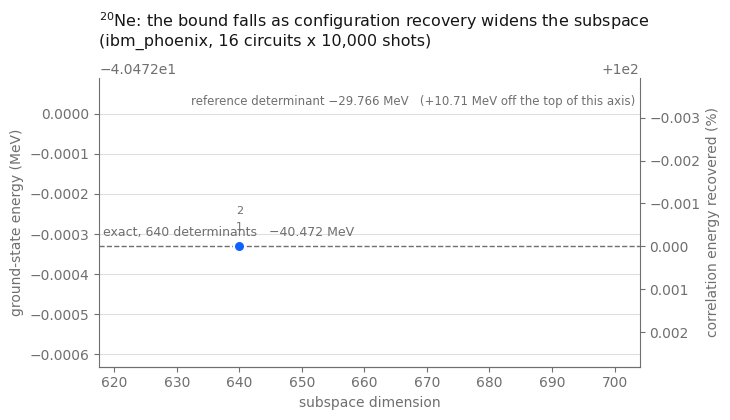

In [20]:
# IBM Carbon palette: Blue 60 and Blue 80 for data, Gray 100/70/30 for ink and rules
SURFACE, INK, MUTED, RULE = "#ffffff", "#161616", "#6f6f6f", "#c6c6c6"
SERIES, DEEP, PURPLE = "#0f62fe", "#002d9c", "#6929c4"


def convergence_plot(
    history, e_ref, e_exact, title, colour=SERIES, full_dim=None
):
    """Energy against subspace dimension, scaled to the data rather than to the full window.

    A good run lands within a fraction of a percent of the exact answer, so an axis spanning
    reference-to-exact would crush every point onto one line.  The axis is therefore scaled to
    the data (plus the exact line, when there is one), and the right-hand axis carries the
    fraction of the correlation energy so the absolute and relative readings sit side by side.
    """
    dimensions = [h["dimension"] for h in history]
    energies = [h["energy"] for h in history]

    fig, ax = plt.subplots(figsize=(7.4, 4.3), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    ax.plot(
        dimensions,
        energies,
        "-o",
        color=colour,
        linewidth=2,
        markersize=8,
        markeredgecolor=SURFACE,
        markeredgewidth=1.5,
        zorder=3,
    )
    stacked = {}
    for h in history:
        # a converged loop repeats the same point; stack the labels so they do not overprint
        key = (round(h["dimension"]), round(h["energy"], 9))
        offset = 12 + 11 * stacked.get(key, 0)
        stacked[key] = stacked.get(key, 0) + 1
        ax.annotate(
            str(h["iteration"]),
            xy=(h["dimension"], h["energy"]),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color=MUTED,
        )

    span = (max(dimensions) - min(dimensions)) or max(1, max(dimensions) // 4)
    x_left, x_right = (
        min(dimensions) - 0.14 * span,
        max(dimensions) + 0.40 * span,
    )
    ax.set_xlim(x_left, x_right)

    floor = min(energies) if e_exact is None else min(min(energies), e_exact)
    height = max(max(energies) - floor, 1e-3)
    ax.set_ylim(floor - 0.30 * height, max(energies) + 0.42 * height)

    if e_exact is not None:
        ax.axhline(
            e_exact, color=MUTED, linestyle="--", linewidth=1, zorder=1
        )
        label = "exact" + (f", {full_dim:,} determinants" if full_dim else "")
        ax.annotate(
            f"{label}   {e_exact:.3f} MeV".replace("-", "\u2212"),
            xy=(x_left, e_exact),
            xytext=(3, 5),
            textcoords="offset points",
            ha="left",
            va="bottom",
            color=MUTED,
            fontsize=9,
        )

    # the reference determinant is far off this scale; state it rather than plotting it
    ax.annotate(
        f"reference determinant {e_ref:.3f} MeV".replace("-", "\u2212")
        + f"   ({e_ref - max(energies):+.2f} MeV off the top of this axis)".replace(
            "-", "\u2212"
        ),
        xy=(x_right, max(energies) + 0.42 * height),
        xytext=(-3, -12),
        textcoords="offset points",
        ha="right",
        va="top",
        color=MUTED,
        fontsize=8.5,
    )

    if e_exact is not None and abs(e_exact - e_ref) > 1e-9:
        right = ax.twinx()
        low, high = ax.get_ylim()

        def to_percent(e):
            return 100 * (e - e_ref) / (e_exact - e_ref)

        right.set_ylim(to_percent(low), to_percent(high))
        right.set_ylabel("correlation energy recovered (%)", color=MUTED)
        right.tick_params(colors=MUTED)
        for side in ("top", "left"):
            right.spines[side].set_visible(False)
        right.spines["right"].set_color(MUTED)
        right.spines["bottom"].set_color(MUTED)

    ax.set_xlabel("subspace dimension", color=MUTED)
    ax.set_ylabel("ground-state energy (MeV)", color=MUTED)
    ax.set_title(title, color=INK, fontsize=11.5, loc="left", pad=12)
    ax.grid(axis="y", color=RULE, alpha=0.55)
    ax.tick_params(colors=MUTED)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color(MUTED)
    fig.tight_layout()
    return fig


convergence_plot(
    result_sd["history"],
    E_REF_SD,
    E_EXACT_SD,
    f"$^{{20}}$Ne: the bound falls as configuration recovery widens the subspace\n"
    f"({backend.name}, {N_CIRCUITS} circuits x {SHOTS:,} shots)",
    full_dim=len(basis_exact_sd),
)
plt.show()

## Large-scale hardware example

Scaling up changes only the inputs, so the next step is to collapse the four stages into one function
and turn the crank twice, both times on a 40-qubit register in the $pf$ shell above a
$^{40}\mathrm{Ca}$ core with the GXPF1 interaction [\[3\]](#references).

The two runs are chosen to separate the two things that "larger" can mean:

- $^{44}\mathrm{Ti}$, two valence protons and two valence neutrons, has a 4,000-determinant basis. The
  register is 40 qubits, but the problem is still small enough to diagonalize exactly on a laptop, so
  the hardware answer can be *scored*. This is the run that tells you the method survived the jump in
  register size.
- $^{48}\mathrm{Cr}$, four and four, has 1,963,461 symmetry-allowed determinants in the same 40 qubits.
  Nothing in this notebook can diagonalize that, so there is no exact number to compare against -- only
  a rigorous upper bound and the reference determinant it improves on. This is the regime the method
  exists for.

Watch two quantities across the two runs. The fraction of the pool that fits inside the fixed gate
budget shrinks as the pool grows, and `pack_ensemble` reports exactly how much made it in. And the
subspace stops being limited by sampling and starts being limited by `MAX_DIMENSION`, the largest
matrix the dense classical solver here will build -- which is the point at which a production
calculation would swap in a selected-CI solver.

### Steps 1-4 compress into single code block

Every stage that follows is the same call the walkthrough made, in the same order.

In [21]:
def sqd_run(snt_file, n_protons, n_neutrons, name, exact=True):
    """The whole workflow for one nucleus.  Returns a record of every stage."""
    # -------------------------Step 1-------------------------
    ms = read_snt(DATA / snt_file, n_protons, n_neutrons)
    sp = m_scheme_states(ms)
    inter = Interaction(ms, sp)
    if sum(1 for s in sp if s.tz == -1) * 2 != len(sp):
        raise ValueError(
            f"{name}: post-selection needs equal proton and neutron state counts"
        )
    reference = reference_determinant(sp, inter, n_protons, n_neutrons)
    e_ref = matrix_element(inter, reference, reference)

    raw = excitation_pool(sp, reference)
    ranked = rank_pool(
        inter, reference, [op for op in raw if conserves_symmetry(sp, op)]
    )
    print(
        f"{name}: {len(sp)} qubits, {n_protons}p + {n_neutrons}n, A = {ms.mass_number}"
    )
    print(
        f"  2p2h pool {len(raw)} raw -> {len(ranked)} symmetry-allowed; "
        f"reference energy {e_ref:.6f} MeV"
    )

    # -------------------------Step 2-------------------------
    costs = excitation_costs(len(sp), ranked, costing_manager)
    circuits, bins, isa = pack_to_budget(
        len(sp),
        reference,
        ranked,
        costs,
        DEPTH_BUDGET,
        N_CIRCUITS,
        pass_manager,
    )
    packed = sum(len(b) for b in bins)
    worst = max(two_qubit_depth(c) for c in isa)
    worst_count = max(two_qubit_count(c) for c in isa)
    print(
        f"  packed {packed} of {len(ranked)} excitations; worst circuit two-qubit depth "
        f"{worst}, {worst_count} two-qubit gates"
    )

    # -------------------------Step 3-------------------------
    # a unique tag per run, so the jobs are findable later
    bit_arrays = sample(isa, SHOTS, JOB_TAGS + [name])
    matrix, probabilities, shots = pool_samples(bit_arrays, sp)
    survival = float(
        probabilities[
            (matrix[:, len(sp) // 2 :].sum(axis=1) == n_protons)
            & (matrix[:, : len(sp) // 2].sum(axis=1) == n_neutrons)
        ].sum()
    )
    print(
        f"  {shots:,} shots -> {len(matrix):,} distinct bitstrings, "
        f"{survival:.1%} of shots with the right nucleon numbers"
    )
    if survival == 0.0:
        raise RuntimeError(
            f"{name}: no shot carried the right nucleon numbers"
        )

    # -------------------------Step 4-------------------------
    result = recovery_loop(
        inter,
        sp,
        matrix,
        probabilities,
        reference,
        n_protons,
        n_neutrons,
        max_iterations=4,
        max_dimension=MAX_DIMENSION,
        seed=42,
    )
    energy = result["energy"]

    full_dim = count_basis(sp, n_protons, n_neutrons)  # cheap, even when huge
    e_exact = None
    if exact:
        full = full_basis(sp, n_protons, n_neutrons)
        if len(full) != full_dim:
            raise AssertionError(
                f"{name}: counted {full_dim} determinants but enumerated "
                f"{len(full)}"
            )
        e_exact, _ = ground_state(inter, full)

    print(f"  reference {e_ref:11.6f} MeV     pooled SQD {energy:11.6f} MeV")
    if e_exact is not None:
        print(
            f"  exact     {e_exact:11.6f} MeV  (dimension {full_dim})  ->  "
            f"{100 * (energy - e_ref) / (e_exact - e_ref):.1f}% of the correlation energy"
        )
        if energy < e_exact - 1e-7:
            raise AssertionError(
                f"{name}: pooled SQD bound is below the exact energy"
            )
    else:
        print(
            f"  no exact reference: the symmetry-allowed basis is {full_dim:,} determinants"
        )
        print(
            f"  the bound captures {energy - e_ref:.6f} MeV of correlation energy"
        )
    print()

    return dict(
        name=name,
        qubits=len(sp),
        pool=len(ranked),
        packed=packed,
        two_qubit=worst,
        two_qubit_gates=worst_count,
        shots=shots,
        distinct=len(matrix),
        survival=survival,
        dimension=len(result["basis"]),
        full_dim=full_dim,
        e_ref=e_ref,
        e_sqd=energy,
        e_exact=e_exact,
        history=result["history"],
        # the subspace and its eigenvector cannot be reconstructed from the summary --
        # they depend on the sampled shots -- so keep them for the scaling analysis
        interaction=inter,
        states=sp,
        reference=reference,
        ranked=ranked,
        basis=result["basis"],
        vector=result["vector"],
    )


pretty = {"20Ne": "$^{20}$Ne", "44Ti": "$^{44}$Ti", "48Cr": "$^{48}$Cr"}

small_scale = dict(
    name="20Ne",
    qubits=len(sp_sd),
    pool=len(ranked_sd),
    packed=PACKED_SD,
    two_qubit=worst_sd,
    two_qubit_gates=worst_count_sd,
    shots=shots_sd,
    distinct=len(matrix_sd),
    survival=shot_survival_sd,
    dimension=len(result_sd["basis"]),
    full_dim=len(basis_exact_sd),
    e_ref=E_REF_SD,
    e_sqd=E_SQD_SD,
    e_exact=E_EXACT_SD,
    history=result_sd["history"],
    interaction=inter_sd,
    states=sp_sd,
    reference=occ_sd,
    ranked=ranked_sd,
    basis=result_sd["basis"],
    vector=result_sd["vector"],
)

### $^{44}\mathrm{Ti}$: the same workflow on a 40-qubit register

The $pf$ shell above $^{40}\mathrm{Ca}$ has four orbitals per species and 20 magnetic substates each,
so the register is 40 qubits. Two valence protons and two valence neutrons make $^{44}\mathrm{Ti}$,
with 4,000 symmetry-allowed determinants -- six times the $^{20}\mathrm{Ne}$ basis on a register
two-thirds larger again.

This is still exactly solvable, which is the point: it is the last rung where the hardware result can
be checked against the truth rather than merely bounded.

In [22]:
large_scale_verified = sqd_run("gxpf1.snt", 2, 2, "44Ti", exact=True)

44Ti: 40 qubits, 2p + 2n, A = 44
  2p2h pool 1602 raw -> 174 symmetry-allowed; reference energy -44.309387 MeV
  packed 96 of 174 excitations; worst circuit two-qubit depth 272, 285 two-qubit gates
job dap31a02fm4c73f67dp0: 16 circuits x 10,000 shots on ibm_phoenix
  160,000 shots -> 48,170 distinct bitstrings, 18.6% of shots with the right nucleon numbers
  iteration 1: 187 proton x 189 neutron halves -> dimension 3891, E = -47.849086 MeV
  iteration 2: 190 proton x 190 neutron halves -> dimension 4000, E = -47.876666 MeV
  iteration 3: 190 proton x 190 neutron halves -> dimension 4000, E = -47.876666 MeV
  reference  -44.309387 MeV     pooled SQD  -47.876666 MeV
  exact      -47.876666 MeV  (dimension 4000)  ->  100.0% of the correlation energy



### $^{48}\mathrm{Cr}$: past the reach of exact diagonalization

Adding two protons and two neutrons costs nothing in qubits -- $^{48}\mathrm{Cr}$ is `4, 4` in the same
40-qubit register -- and multiplies the basis by 491, to 1,963,461 symmetry-allowed determinants. That
matrix is far beyond anything this notebook will build, so `exact=False`: there is no reference energy,
only the variational bound and the reference determinant it improves on.

Two things change at this scale, and both are visible in the printout. The pool grows to several
hundred allowed excitations, so the fixed gate budget now covers a minority of it rather than all of
it. And the product subspace the samples span is larger than `MAX_DIMENSION`, so the dense solver
truncates it by sampled weight -- the bound stays rigorous, it is simply not as tight as the samples
would allow. A production calculation would keep the samples and replace the solver, not the other way
round.

In [23]:
large_scale_unverified = sqd_run("gxpf1.snt", 4, 4, "48Cr", exact=False)

48Cr: 40 qubits, 4p + 4n, A = 48
  2p2h pool 5536 raw -> 582 symmetry-allowed; reference energy -93.041237 MeV
  packed 96 of 582 excitations; worst circuit two-qubit depth 224, 279 two-qubit gates
job dap32a02fm4c73f67eog: 16 circuits x 10,000 shots on ibm_phoenix
  160,000 shots -> 55,436 distinct bitstrings, 18.6% of shots with the right nucleon numbers
  iteration 1: 223 proton x 223 neutron halves -> dimension 3977, E = -96.481598 MeV
  iteration 2: 223 proton x 223 neutron halves -> dimension 3977, E = -96.481598 MeV
  reference  -93.041237 MeV     pooled SQD  -96.481598 MeV
  no exact reference: the symmetry-allowed basis is 1,963,461 determinants
  the bound captures -3.440361 MeV of correlation energy



### Read a result with nothing to compare it to

The $^{48}\mathrm{Cr}$ run returns one number and no way to check it, which is the situation any
useful quantum calculation eventually finds itself in. Two questions decide whether that number is
worth anything, and both can be answered from the samples already taken -- no more QPU time, no exact
diagonalization.

**Is it converged?** Reorder the retained determinants by their weight in the converged eigenvector
and the subspaces become *nested*, so diagonalizing the leading $d \times d$ block for a ladder of $d$
traces the bound's descent across two decades of subspace size. If it is still falling steeply at the
largest $d$, the classical solver's dimension cap is the binding constraint and `MAX_DIMENSION` is the
knob to turn. If it has flattened, the cap is not what is holding you back -- the sampling is. The
Hamiltonian is built once at full size and every rung is a principal block of it, so the whole
sweep costs one matrix build rather than one per rung.

**Did the quantum sampler earn its keep?** The honest comparison is against the best subspace of the
*same size* that classical selection would have chosen: take the pool ranked by perturbation theory in score
order, grow the product subspace to the same dimension, and diagonalize that instead. Both curves are
rigorous upper bounds on the same Hamiltonian, so whichever sits lower at equal dimension picked the
better determinants. This is the comparison that decides whether sampling on hardware bought anything
that ranking on a laptop would not.

One thing this subspace is *not* good for: excited states. Configuration recovery steers the subspace
using ground-state occupancies, so the higher eigenvalues are much further from converged than the
lowest one, and the first excitation energy comes out well above the measured $2^+$. Reaching excited
states properly needs a subspace selected for them.

In [24]:
def subspace_scaling(
    inter, basis, vector, points=18, smallest=32, largest=None
):
    """Nested Rayleigh-Ritz sweep: the lowest eigenvalue of the leading d x d block, for a ladder of d.

    Reordering the basis by descending weight in the converged eigenvector makes every subspace in
    the ladder a subset of the next, so the energies fall monotonically and each one is a valid
    variational bound.  H is built once at full size; each rung is a principal block.
    """
    order = np.argsort(-(np.abs(vector) ** 2))
    ordered = [basis[i] for i in order]
    weights = (np.abs(vector) ** 2)[order]
    if (
        largest is not None
    ):  # cap the ladder so two subspaces end at a common dimension
        ordered, weights = ordered[:largest], weights[:largest]
    H = subspace_hamiltonian(inter, ordered)
    dimensions = np.unique(
        np.geomspace(smallest, len(ordered), points).astype(int)
    )
    rows = [
        (
            int(d),
            float(
                eigh(H[:d, :d], eigvals_only=True, subset_by_index=[0, 0])[0]
            ),
        )
        for d in dimensions
    ]
    return rows, np.cumsum(weights)


def classical_selection(
    inter, sp, reference, ranked, target, n_protons, n_neutrons
):
    """The subspace classical perturbative ranking would pick, grown to `target` dimension.

    Same product construction as the sampled subspace, and the same truncation discipline -- half
    configurations are offered to `grow_subspace` in order of importance and it takes as many as
    fit.  The only difference from the sampled path is where the ordering comes from: PT2 score
    here, measured sampling weight there.  So the comparison isolates *which determinants got
    chosen* and nothing else.

    Truncating by any other rule would not be a fair baseline.  Slicing an arbitrarily ordered
    list, for instance, keeps determinants by accident rather than by importance and makes the
    classical subspace look worse than classical selection really is.
    """
    p_ref = tuple(i for i in reference if sp[i].tz == -1)
    n_ref = tuple(i for i in reference if sp[i].tz == +1)
    reached = {reference}
    proton_order, neutron_order = [p_ref], [n_ref]
    seen_p, seen_n = {p_ref}, {n_ref}
    product_budget = 4 * target

    for op, _, _ in ranked:  # ranked is already in descending PT2 score
        h1, h2, v1, v2 = op
        fresh = {
            tuple(sorted(set(d) - {h1, h2} | {v1, v2}))
            for d in reached
            if {h1, h2} <= set(d) and not {v1, v2} & set(d)
        }
        reached |= fresh
        for det in fresh:  # first appearance fixes a half's rank
            half_p = tuple(i for i in det if sp[i].tz == -1)
            half_n = tuple(i for i in det if sp[i].tz == +1)
            if half_p not in seen_p:
                seen_p.add(half_p)
                proton_order.append(half_p)
            if half_n not in seen_n:
                seen_n.add(half_n)
                neutron_order.append(half_n)
        if len(proton_order) * len(neutron_order) > product_budget:
            # Half-configuration products over-count the subspace, because only the
            # symmetry-allowed ones survive `product_subspace`.  Stopping on the product
            # count alone can therefore leave the basis far short of `target`, so check
            # the dimension actually realized and widen the budget if it falls short.
            trial, _, _ = grow_subspace(
                sp,
                [p_ref],
                [n_ref],
                proton_order,
                neutron_order,
                n_protons,
                n_neutrons,
                max_dimension=target,
            )
            if len(trial) >= target:
                break
            product_budget *= 2

    basis, _, _ = grow_subspace(
        sp,
        [p_ref],
        [n_ref],
        proton_order,
        neutron_order,
        n_protons,
        n_neutrons,
        max_dimension=target,
    )
    return basis


run = large_scale_unverified
if "basis" not in run:
    raise RuntimeError(
        "this cell needs the subspace and eigenvector that sqd_run now returns; "
        "re-run the sqd_run definition and the 48Cr cell"
    )

print(
    f"{run['name']}: sweeping nested subspaces of the sampled basis "
    f"(dimension {run['dimension']})"
)
sampled_rows, cumulative = subspace_scaling(
    run["interaction"], run["basis"], run["vector"]
)

print(
    f"{run['name']}: building the classically selected subspace at the same dimension"
)
classical_basis = classical_selection(
    run["interaction"],
    run["states"],
    run["reference"],
    run["ranked"],
    run["dimension"],
    4,
    4,
)
# Both subspaces must be scored at the same dimension.  Symmetry filtering can still leave
# the classical construction short of the target when the ranked pool runs out, so take the
# dimension both actually reach, cap both ladders there, and verify they agree.
common_dim = min(sampled_rows[-1][0], len(classical_basis))
if common_dim < sampled_rows[-1][0]:
    sampled_rows, _ = subspace_scaling(
        run["interaction"], run["basis"], run["vector"], largest=common_dim
    )
classical_rows, _ = subspace_scaling(
    run["interaction"],
    classical_basis,
    ground_state(run["interaction"], classical_basis)[1],
    largest=common_dim,
)
if sampled_rows[-1][0] != classical_rows[-1][0]:
    raise RuntimeError(
        f"comparison dimensions differ: sampled {sampled_rows[-1][0]}, "
        f"classical {classical_rows[-1][0]}"
    )

advantage = sampled_rows[-1][1] - classical_rows[-1][1]
direction = "lower" if advantage < 0 else "higher"
verdict = "beats" if advantage < 0 else "does not beat"
descent = next(
    e for d, e in reversed(sampled_rows) if d <= sampled_rows[-1][0] / 2
)
for fraction in (0.90, 0.99):
    count = int(np.searchsorted(cumulative, fraction) + 1)
    print(
        f"  {fraction:.0%} of the eigenvector norm sits on {count} determinants "
        f"({count / run['full_dim']:.1e} of the {run['full_dim']:,}-determinant space)"
    )
print(
    f"  bound still falling {1000 * (sampled_rows[-1][1] - descent):+.1f} keV "
    f"over the last doubling of dimension"
)
print(
    f"  sampled {sampled_rows[-1][1]:.6f} MeV vs classically selected "
    f"{classical_rows[-1][1]:.6f} MeV at a verified common dimension of "
    f"{classical_rows[-1][0]:,}"
)
print(
    f"  -> the sampled subspace is {abs(advantage) * 1000:.0f} keV {direction}"
)

48Cr: sweeping nested subspaces of the sampled basis (dimension 3977)
48Cr: building the classically selected subspace at the same dimension
  90% of the eigenvector norm sits on 107 determinants (5.4e-05 of the 1,963,461-determinant space)
  99% of the eigenvector norm sits on 593 determinants (3.0e-04 of the 1,963,461-determinant space)
  bound still falling -15.6 keV over the last doubling of dimension
  sampled -96.481598 MeV vs classically selected -95.314510 MeV at a verified common dimension of 3,957
  -> the sampled subspace is 1167 keV lower


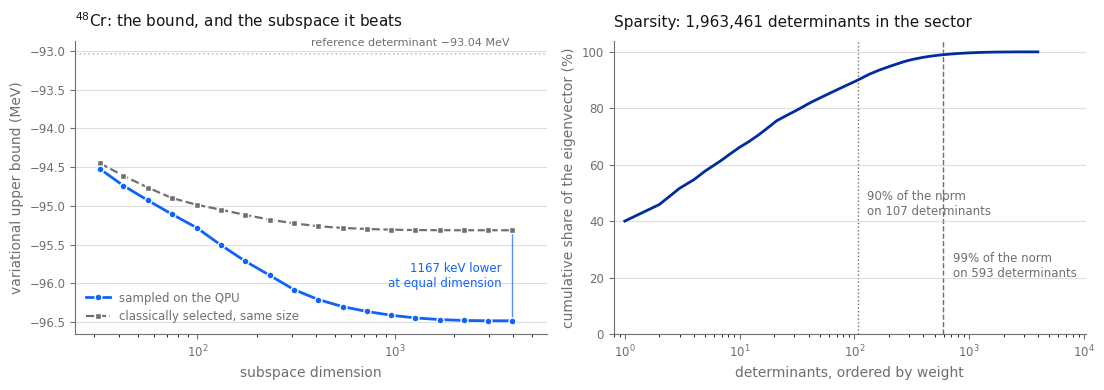

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), facecolor=SURFACE)

# left: two nested convergence curves on the same axes
ax = axes[0]
ax.set_facecolor(SURFACE)
ax.plot(
    [d for d, _ in sampled_rows],
    [e for _, e in sampled_rows],
    "-o",
    color=SERIES,
    linewidth=2,
    markersize=5,
    markeredgecolor=SURFACE,
    markeredgewidth=1,
    zorder=4,
    label="sampled on the QPU",
)
ax.plot(
    [d for d, _ in classical_rows],
    [e for _, e in classical_rows],
    "--s",
    color=MUTED,
    linewidth=1.6,
    markersize=4,
    markeredgecolor=SURFACE,
    markeredgewidth=1,
    zorder=3,
    label="classically selected, same size",
)
ax.axhline(run["e_ref"], color=RULE, linestyle=":", linewidth=1.2, zorder=1)
ax.annotate(
    f"reference determinant {run['e_ref']:.2f} MeV".replace("-", "\u2212"),
    xy=(sampled_rows[-1][0], run["e_ref"]),
    xytext=(-2, 4),
    textcoords="offset points",
    ha="right",
    va="bottom",
    color=MUTED,
    fontsize=8,
)

# mark the gap between the two curves at the largest dimension, not either curve alone
edge = sampled_rows[-1][0]
ax.plot(
    [edge, edge],
    [classical_rows[-1][1], sampled_rows[-1][1]],
    "-",
    color=SERIES,
    linewidth=1.0,
    alpha=0.7,
    zorder=2,
)
ax.annotate(
    f"{abs(advantage) * 1000:.0f} keV {direction}\nat equal dimension",
    xy=(edge, 0.5 * (classical_rows[-1][1] + sampled_rows[-1][1])),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color=SERIES,
    fontsize=8.5,
)

ax.set_xscale("log")
ax.set_xlim(sampled_rows[0][0] * 0.75, edge * 1.5)
ax.set_xlabel("subspace dimension", color=MUTED)
ax.set_ylabel("variational upper bound (MeV)", color=MUTED)
ax.set_title(
    f"{pretty[run['name']]}: the bound, and the subspace it {verdict}",
    color=INK,
    fontsize=11,
    loc="left",
    pad=10,
)
legend = ax.legend(frameon=False, fontsize=8.5, loc="lower left")
for text in legend.get_texts():
    text.set_color(MUTED)

# right: why a few thousand determinants can bound two million
ax = axes[1]
ax.set_facecolor(SURFACE)
ranks = np.arange(1, len(cumulative) + 1)
ax.plot(ranks, 100 * cumulative, "-", color=DEEP, linewidth=2, zorder=3)
for fraction, style, label_y in ((0.90, ":", 46), (0.99, "--", 24)):
    count = int(np.searchsorted(cumulative, fraction) + 1)
    ax.axvline(count, color=MUTED, linestyle=style, linewidth=1, zorder=1)
    ax.annotate(
        f"{fraction:.0%} of the norm\non {count} determinants",
        xy=(count, label_y),
        xytext=(7, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        color=MUTED,
        fontsize=8.5,
    )
ax.set_xscale("log")
ax.set_xlim(0.8, len(cumulative) * 2.6)
ax.set_ylim(0, 104)
ax.set_xlabel("determinants, ordered by weight", color=MUTED)
ax.set_ylabel("cumulative share of the eigenvector (%)", color=MUTED)
ax.set_title(
    f"Sparsity: {run['full_dim']:,} determinants in the sector",
    color=INK,
    fontsize=11,
    loc="left",
    pad=10,
)

for ax in axes:
    ax.grid(axis="y", color=RULE, alpha=0.55)
    ax.tick_params(colors=MUTED, labelsize=8.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color(MUTED)
fig.tight_layout()
plt.show()

### Compare the three runs

Absolute energies are not comparable across different nuclei and different interactions, so the
quantity to read across runs is the fraction of the correlation energy recovered -- where there is an
exact answer to take a fraction of -- together with what it cost in circuit depth and in discarded
shots.

In [26]:
runs = [small_scale, large_scale_verified, large_scale_unverified]

print(
    f"{'run':>6}  {'qubits':>6}  {'pool':>9}  {'2q depth':>8}  {'2q gates':>8}  "
    f"{'shots kept':>10}  {'dim':>6}  {'of':>9}  {'% corr':>7}"
)
for r in runs:
    fraction = (
        "--"
        if r["e_exact"] is None
        else f"{100 * (r['e_sqd'] - r['e_ref']) / (r['e_exact'] - r['e_ref']):.1f}%"
    )
    coverage = "{}/{}".format(r["packed"], r["pool"])
    print(
        f"{r['name']:>6}  {r['qubits']:>6}  {coverage:>9}  "
        f"{r['two_qubit']:>8}  {r['two_qubit_gates']:>8}  {r['survival']:>9.1%}  "
        f"{r['dimension']:>6}  {(r['full_dim'] or 0):>9,}  {fraction:>7}"
    )

print()
for r in runs:
    exact = (
        f"exact {r['e_exact']:11.6f}"
        if r["e_exact"] is not None
        else "exact  unavailable"
    )
    print(
        f"{r['name']:>6}   reference {r['e_ref']:11.6f}   pooled SQD {r['e_sqd']:11.6f}   {exact} MeV"
    )

   run  qubits       pool  2q depth  2q gates  shots kept     dim         of   % corr
  20Ne      24      78/78       228       234      31.5%     640        640   100.0%
  44Ti      40     96/174       272       285      18.6%    4000      4,000   100.0%
  48Cr      40     96/582       224       279      18.6%    3977  1,963,461       --

  20Ne   reference  -29.765549   pooled SQD  -40.472331   exact  -40.472331 MeV
  44Ti   reference  -44.309387   pooled SQD  -47.876666   exact  -47.876666 MeV
  48Cr   reference  -93.041237   pooled SQD  -96.481598   exact  unavailable MeV


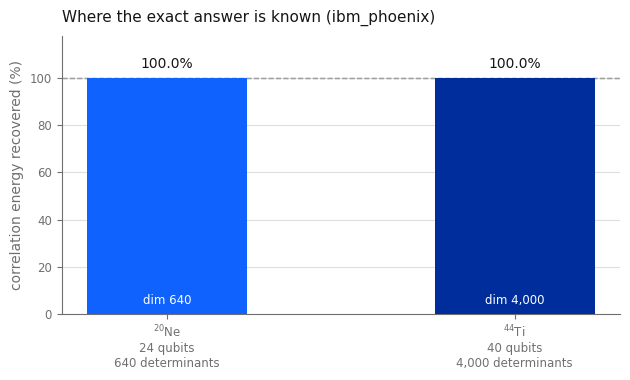

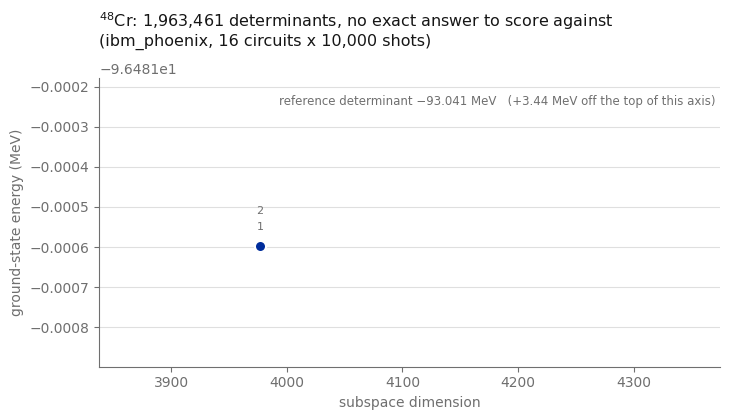

In [27]:
# Left: how much of the correlation energy was recovered, where the exact answer is known.
# Right: the bound itself for the run that has nothing to score against.
scored = [r for r in runs if r["e_exact"] is not None]

fig, ax = plt.subplots(figsize=(6.4, 3.9), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
labels = [
    f"{pretty[r['name']]}\n{r['qubits']} qubits\n{r['full_dim']:,} determinants"
    for r in scored
]
fractions = [
    100 * (r["e_sqd"] - r["e_ref"]) / (r["e_exact"] - r["e_ref"])
    for r in scored
]
shades = [SERIES, DEEP, PURPLE]
bars = ax.bar(
    labels, fractions, width=0.46, color=shades[: len(scored)], zorder=3
)
for bar, fraction, r in zip(bars, fractions, scored):
    ax.annotate(
        f"{fraction:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, fraction),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=10,
    )
    ax.annotate(
        f"dim {r['dimension']:,}",
        xy=(bar.get_x() + bar.get_width() / 2, 3),
        ha="center",
        va="bottom",
        color=SURFACE,
        fontsize=8.5,
    )
ax.axhline(100, color=MUTED, linestyle="--", linewidth=1, zorder=1)
ax.annotate(
    "exact diagonalization",
    xy=(-0.45, 100),
    xytext=(0, 4),
    textcoords="offset points",
    ha="left",
    va="bottom",
    color=MUTED,
    fontsize=8.5,
)
ax.set_ylim(0, 118)
ax.set_ylabel("correlation energy recovered (%)", color=MUTED)
ax.set_title(
    f"Where the exact answer is known ({backend.name})",
    color=INK,
    fontsize=11,
    loc="left",
    pad=10,
)
ax.grid(axis="y", color=RULE, alpha=0.55)
ax.tick_params(colors=MUTED, labelsize=8.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("bottom", "left"):
    ax.spines[side].set_color(MUTED)
fig.tight_layout()
plt.show()

# the same convergence view as the walkthrough, for the run with no exact reference
convergence_plot(
    large_scale_unverified["history"],
    large_scale_unverified["e_ref"],
    None,
    f"{pretty[large_scale_unverified['name']]}: "
    f"{large_scale_unverified['full_dim']:,} determinants, no exact answer to score against\n"
    f"({backend.name}, {N_CIRCUITS} circuits x {SHOTS:,} shots)",
    colour=DEEP,
)
plt.show()

## Summary

One workflow, unchanged apart from its inputs, ran on a QPU at three problem sizes: a 24-qubit
problem you can check exactly, a 40-qubit problem you can still check exactly, and a 40-qubit problem
with nearly two million basis states that you cannot.

What the three runs together establish:

- **The quantum step only has to propose determinants.** The circuit is fixed, seeded from
  second-order perturbation theory, and never optimized. Nothing in the workflow needs its amplitudes
  to be accurate -- only its support to be useful -- and that is what makes the answer a rigorous
  variational bound rather than an estimate with an error bar.
- **That freedom buys real depth.** Because only the support matters, the fermionic excitation blocks
  can be replaced by qubit excitations, whose cost does not grow with the distance between the
  orbitals they connect. Step 2 measured the saving on the actual backend: it is the difference
  between a circuit that fits comfortably inside coherence and one that does not.
- **Noise is spent, not suffered.** Every shot with the wrong proton or neutron number is repaired
  against the current occupancy estimate rather than discarded, and each repaired half-configuration
  widens the subspace. Widening a variational subspace cannot raise its lowest eigenvalue, so a
  noisier run can give a *better* bound -- an effect a simulator cannot show you.
- **The binding constraint moves as you scale.** At 24 qubits the ansatz could reach the exact answer
  and only sampling stood in the way. At 40 qubits with four valence nucleons per species, the gate
  budget covers a minority of the pool and the dense classical solver caps the subspace. Knowing which
  of the three is limiting you is the practical skill this workflow teaches.

## Next steps

If you found this work interesting, you might be interested in the following material:

<Admonition type="tip" title="Recommendations">

- [Sample-based quantum diagonalization of a chemistry Hamiltonian](/docs/tutorials/sample-based-quantum-diagonalization) -- the same algorithm applied to electronic structure, using the addon's selected-CI solver
- [SQD addon documentation](/docs/api/qiskit-addon-sqd) -- post-selection, subsampling and configuration-recovery utilities
- [Quantum diagonalization algorithms](https://learning.quantum.ibm.com/course/quantum-diagonalization-algorithms) -- a full course on subspace diagonalization, including Krylov variants
- [Transpile against a backend target](/docs/guides/transpile) -- the pass-manager options that matter when a circuit is dominated by two-qubit gates
- [Execution modes](/docs/guides/execution-modes) -- batch the three runs into one submission instead of three jobs

</Admonition>

Concrete extensions of this notebook:

- **Replace the dense solver.** `MAX_DIMENSION` is the ceiling on everything at the $^{48}\mathrm{Cr}$
  scale, and `np.linalg.eigh` on a dense matrix is why. A selected-CI solver exploits the
  proton $\times$ neutron product structure the subspace already has; the addon's
  `qiskit_addon_sqd.fermion.solve_sci` is built on exactly that structure. This is the single change
  that would move the large-scale run from a few thousand determinants to a few hundred thousand.
- **Add batching and subsampling.** The published pooled SQD workflow diagonalizes several independent
  subsamples per iteration and keeps the best. This notebook uses one batch per iteration, which is
  harmless for the variational bound but throws away the variance information that tells you whether more shots
  would help.
- **Excited states and other sectors.** The higher eigenvalues of each subspace Hamiltonian are upper
  bounds on excited states in the same symmetry sector, and running at $M_J \neq 0$ reaches other
  sectors. The $2^+$ check in Step 1 is already half of this calculation.
- **A cross-shell model space.** Parity is automatically satisfied inside a single major shell, which
  is why it does no work here. An $sd$-$pf$ space mixes $\ell$ parities, making parity a genuine
  fourth constraint -- and one that neither the addon's Hamming-weight repair nor the product
  construction would catch on its own.
- **Odd-mass nuclei.** `reference_determinant` requires an even valence count in each species,
  because a time-reversed paired filling is what forces $M_J = 0$. An odd nucleus needs a
  half-integer $M_J$ target and an unpaired reference.

## Appendix

<a id="appendix"></a>

The [Setup](#setup) section says what each helper does. This section says why it is right.

### Why the mass-dependence rescaling is not optional

Empirical shell-model interactions are fitted at one mass and applied across a chain of isotopes, with
the two-body matrix elements scaled as $(A/A_{\mathrm{ref}})^{p}$. Both interaction files carry
$p = -0.3$, with $A_{\mathrm{ref}} = 18$ for the USD family and $42$ for GXPF1. On the two-body header
line of a `.snt` file those two numbers sit where an oscillator frequency and a core energy would
plausibly go, which makes them easy to misread; reading the exponent as a constant core energy adds a
spurious offset to every diagonal element *and* drops the rescaling, changing the correlation energy by
a few percent. The check in Step 1 catches neither error on its own, which is why the $2^+$ excitation
energy is compared against experiment there: it is a dimensionless, measured quantity that a
mis-scaled Hamiltonian will not reproduce.

### Why the reference is found by search rather than by filling

The obvious reference is the determinant that fills the lowest single-particle energies. It is not the
lowest-energy determinant, because the diagonal of Eq. (1) includes the two-body term
$\sum_{i<j} \langle ij \| ij \rangle$, and the pairing interaction strongly prefers occupying
time-reversed $(+m_j, -m_j)$ partners in the *largest* available $|m_j|$. In the $sd$ shell that is the
difference between the $m_j = \pm 1/2$ pair and the $m_j = \pm 5/2$ pair of $0d_{5/2}$, and it is worth
about 1 MeV; in the $pf$ shell, closer to 2. Because the reference energy is the zero of the
"correlation energy recovered" metric, choosing it badly inflates that metric while making the
starting point worse.

Restricting to paired fillings makes exhaustive search cheap -- $\binom{n_{\mathrm{pairs}}}{k}$ per
species, a few thousand candidates at most -- and forces $M_J = 0$ for free. In every case in this
notebook that can be checked against a full enumeration, the search returns the global lowest-diagonal
determinant, which is also the single largest component of the exact ground state.

### Why the first-order amplitude, not the exact two-level angle

Diagonalizing the $2 \times 2$ Hamiltonian in the space
$\{|\Phi_{\mathrm{ref}}\rangle, |\alpha\rangle\}$ gives the mixing angle
$\theta_{\mathrm{exact}} = \tfrac{1}{2}\arctan(2V/\Delta)$, and it is tempting to call that the correct
choice. For an *isolated* pair of levels it is. This ansatz is not that: several dozen excitation
blocks act in sequence on the same reference, so no per-block two-level solution is the optimum of the
composite circuit anyway.

What decides it is what the circuit is for. Since
$|\tfrac{1}{2}\arctan(2x)| \le |x|$ for every real $x$, the exact angle is always *smaller* in
magnitude than the first-order amplitude $t = V/\Delta$, and therefore always leaves *more* amplitude
on the reference determinant. A circuit that keeps more amplitude on the reference returns the
reference more often and distinct excited determinants less often. For pooled SQD the useful output of a shot
is a determinant the classical step has not seen yet, so the larger angle is the better choice here --
and neither angle needs to be accurate, because the classical diagonalization discards the circuit's
amplitudes entirely and re-derives its own.

### Why dropping the Jordan-Wigner $Z$ strings is safe here

The fermionic excitation $T = a_{v_1}^\dagger a_{v_2}^\dagger a_{h_2} a_{h_1}$ maps under
Jordan-Wigner to eight Pauli strings, each carrying $Z$ operators on every qubit between the outermost
indices. Those strings encode the fermionic sign, and their cost grows with the span -- which for a
proton-neutron excitation is the whole register.

Deleting them gives the qubit-excitation operator of Yordanov et al. [\[5\]](#references). It is a
genuinely different operator: the state it prepares differs from the fermionic one in the *signs* of
its amplitudes, and the two sampling distributions can differ substantially. What it does not change
is which determinants have nonzero amplitude, because each block still rotates within the same
two-dimensional space $\{|d\rangle, |d'\rangle\}$ for every determinant $d$ it acts on, and it still
conserves both nucleon numbers, $M_J$ and parity exactly. The reachable set of determinants is
therefore identical, and the reachable set is the only thing pooled SQD consumes -- the classical
diagonalization assigns its own amplitudes regardless. Step 2 verifies the identical-support claim on
a real operator from the pool and measures what the substitution saves.

The honest caveat is that the sampling *weights* differ, so the two constructions will not discover
determinants in the same order at finite shot count. Since the ranking that decides which excitations
enter the circuits is classical and unchanged, and the classical step re-weights everything anyway,
that difference costs far less than the depth it buys.

### Why $M_J$ belongs to the product stage

Post-selection and configuration recovery both act on Hamming weights: the number of protons in one
half of the register and the number of neutrons in the other. $M_J = M_p + M_n$ is not of that form --
it is a property of a proton configuration *paired with* a neutron configuration. A shot whose proton
half and neutron half each carry the right nucleon number contains two usable half-configurations even
when their $M_J$ values do not cancel, because the proton half at $M_p = +1$ is perfectly good once it
is paired with a neutron half at $M_n = -1$. Filtering whole shots on total $M_J$ throws both halves
away; imposing $M_J$ on the recombined products keeps them. The same argument explains why
`recover_configurations` needs no notion of $M_J$ to be useful here.

## References

<a id="references"></a>

1. J. Robledo-Moreno, M. Motta, H. Haas, et al., "Chemistry beyond the scale of exact diagonalization
   on a quantum-centric supercomputer", *Science Advances* **11**, eadu9991 (2025).
   [arXiv:2405.05068](https://arxiv.org/abs/2405.05068)
2. B. A. Brown and W. A. Richter, "New USD Hamiltonians for the sd shell", *Physical Review C* **74**,
   034315 (2006). The embedded `usda.snt` file carries the USDA parameters as tabulated by
   W. A. Richter, S. Mkhize and B. A. Brown, "sd-shell observables for the USDA and USDB Hamiltonians",
   *Physical Review C* **78**, 064302 (2008).
3. M. Honma, T. Otsuka, B. A. Brown and T. Mizusaki, "Effective interaction for pf-shell nuclei",
   *Physical Review C* **65**, 061301(R) (2002).
4. B. Huron, J. P. Malrieu and P. Rancurel, "Iterative perturbation calculations of ground and excited
   state energies from multiconfigurational zeroth-order wavefunctions", *The Journal of Chemical
   Physics* **58**, 5745 (1973).
5. Y. S. Yordanov, D. R. M. Arvidsson-Shukur and C. H. W. Barnes, "Efficient quantum circuits for
   quantum computational chemistry", *Physical Review A* **102**, 062612 (2020).
6. National Nuclear Data Center, [Evaluated Nuclear Structure Data File](https://www.nndc.bnl.gov/ensdf/),
   Brookhaven National Laboratory. Source of the measured $2^+$ excitation energies quoted in Step 1.